# Comparison of Unidirectional and Bidirection pi_add in Nonlinear Simulation by changing k_add

In [ ]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor, as_completed

# ============================================================
# Paths (UPDATED)
# ============================================================
ROOT_DIR = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects"

# Run metadata is JSON-lines but stored as .log
RUNLOG_PATH = os.path.join(ROOT_DIR, "A_and_B.log")

# Event logs directory
EVENTLOG_DIR = os.path.join(ROOT_DIR, "A_and_B")  # contains event_log_rows_*.csv

# ============================================================
# IMPORTANT: total simulation duration
# If event log time is in HOURS -> 48.0
# If event log time is in SECONDS -> 48*3600
# ============================================================
T_TOTAL = 48.0


# ============================================================
# Fast π_on from event log (vectorized, correct interval semantics)
# ============================================================
def compute_pi_on_per_cell_gene_fast(event_csv_path: str, T_total: float = T_TOTAL) -> pd.DataFrame:
    """
    Each row: at time t_i, the state becomes new_state starting at t_i.
    new_state holds on interval [t_i, next_t_i) within same (cell,gene).
    Assume initial state at t=0 is OFF (0).
    Compute π_on over [0, T_total].
    """
    usecols = ["cell", "gene", "time", "new_state"]
    dtypes = {"cell": "int32", "gene": "int16", "time": "float64", "new_state": "int8"}

    df = pd.read_csv(event_csv_path, usecols=usecols, dtype=dtypes)
    if df.empty:
        return pd.DataFrame(columns=["cell", "gene", "pi_on"])

    df = df[(df["time"] >= 0.0) & (df["time"] <= T_total)].copy()
    if df.empty:
        return pd.DataFrame(columns=["cell", "gene", "pi_on"])

    df = df.sort_values(["cell", "gene", "time"], kind="mergesort")
    next_time = df.groupby(["cell", "gene"], sort=False)["time"].shift(-1).fillna(T_total)

    t = df["time"].to_numpy()
    nt = next_time.to_numpy()
    dur = np.clip(nt - t, 0.0, None)

    state = df["new_state"].to_numpy()
    on_dur = np.where(state == 1, dur, 0.0)

    tmp = df[["cell", "gene"]].copy()
    tmp["on_dur"] = on_dur

    on_time = tmp.groupby(["cell", "gene"], sort=False)["on_dur"].sum().reset_index()
    on_time["pi_on"] = on_time["on_dur"] / float(T_total)
    return on_time[["cell", "gene", "pi_on"]]


# ============================================================
# Robustly resolve event csv path using glob (DO NOT construct exact name)
# Matches filenames like:
# event_log_rows_0_0_0_17022026_174052_ncells_6000_A_and_B_k_add_6_4_4_<suffix>.csv
# ============================================================
def resolve_eventlog(eventlog_dir: str, rr, ts, n_cells, run_type, run_id=None) -> str | None:
    if rr is None or len(rr) == 0:
        return None

    rr_str = "_".join(str(x) for x in rr)
    ts_str = str(ts)
    n_cells_str = str(n_cells)
    run_type_str = str(run_type)

    patterns = []
    # Most specific: include id if it exists somewhere in filename
    if run_id is not None:
        patterns.append(
            os.path.join(
                eventlog_dir,
                f"event_log_rows_{rr_str}_{ts_str}_ncells_{n_cells_str}_{run_type_str}_*{run_id}*.csv"
            )
        )
    # Usual pattern
    patterns.append(
        os.path.join(
            eventlog_dir,
            f"event_log_rows_{rr_str}_{ts_str}_ncells_{n_cells_str}_{run_type_str}_*.csv"
        )
    )
    # Fallbacks if naming changes slightly
    patterns.append(os.path.join(eventlog_dir, f"*rows_{rr_str}*{ts_str}*ncells_{n_cells_str}*{run_type_str}*.csv"))

    for pat in patterns:
        hits = glob.glob(pat)
        if hits:
            hits.sort(key=os.path.getsize, reverse=True)
            return hits[0]

    return None


# ============================================================
# Read runlog metadata (.log JSONL) and map to event logs
# ============================================================
def load_run_table(runlog_path: str) -> pd.DataFrame:
    rows_out = []
    with open(runlog_path, "r") as f:
        for line in f:
            if not line.strip():
                continue
            rec = json.loads(line)

            run_id = rec.get("id")
            rr = rec.get("rows", None)               # typically [0,0,0] now
            n_cells = rec.get("n_cells", None)
            run_type = rec.get("type", None)
            ts = rec.get("timestamp", None)          # e.g. "17022026_174052"
            p = rec.get("param_dict", {}) or {}

            if run_id is None or ts is None or run_type is None or n_cells is None:
                continue
            if rr is None or len(rr) < 2:
                continue

            # k_add present only in one direction in this dataset
            k12 = p.get("{k_add_gene_1}")
            k12 = float(k12) if k12 is not None else np.nan

            event_path = resolve_eventlog(EVENTLOG_DIR, rr, ts, n_cells, run_type, run_id=run_id)

            rows_out.append({
                "id": run_id,
                "rows": rr,
                "timestamp": str(ts),
                "n_cells": int(n_cells),
                "type": run_type,
                "k_add_12": k12,
                "event_log": event_path
            })

    return pd.DataFrame(rows_out)


# ============================================================
# Parallel processing across files
# ============================================================
def _process_one_run(rowdict: dict) -> pd.DataFrame:
    event_log = rowdict["event_log"]
    df_pi = compute_pi_on_per_cell_gene_fast(event_log, T_total=T_TOTAL)

    df_pi["id"] = rowdict["id"]
    df_pi["timestamp"] = rowdict["timestamp"]
    df_pi["k_add_12"] = float(rowdict["k_add_12"])
    df_pi["type"] = rowdict["type"]
    df_pi["event_log"] = event_log
    return df_pi


def compute_all_runs_parallel(run_df: pd.DataFrame, n_workers: int = None) -> pd.DataFrame:
    if n_workers is None:
        n_workers = max(1, min(16, (os.cpu_count() or 2) // 2))

    rows = run_df.to_dict(orient="records")
    out = []

    with ProcessPoolExecutor(max_workers=n_workers) as ex:
        futs = [ex.submit(_process_one_run, r) for r in rows]
        for fut in as_completed(futs):
            out.append(fut.result())

    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


# ============================================================
# Main
# ============================================================
def main(
    restrict_type=None,          # set to e.g. "A_and_B_k_add_6_4_4" if you want
    genes_to_include=(0, 1),
    n_workers=16,
    showfliers=False,
    save_png=None
):
    print("RUNLOG exists:", os.path.exists(RUNLOG_PATH), RUNLOG_PATH)
    print("EVENTLOG_DIR exists:", os.path.isdir(EVENTLOG_DIR), EVENTLOG_DIR)

    run_df = load_run_table(RUNLOG_PATH)
    if run_df.empty:
        raise RuntimeError(f"No runs loaded from runlog: {RUNLOG_PATH}")

    if restrict_type is not None:
        run_df = run_df[run_df["type"] == restrict_type].copy()

    # keep only resolved event logs
    run_df["exists"] = run_df["event_log"].apply(lambda x: isinstance(x, str) and os.path.exists(x))
    if (~run_df["exists"]).any():
        print(f"[WARN] Missing/unresolved event logs: {(~run_df['exists']).sum()} (showing 10)")
        print(run_df.loc[~run_df["exists"], ["timestamp", "type", "rows", "n_cells", "id", "event_log"]]
              .head(10).to_string(index=False))
    run_df = run_df[run_df["exists"]].copy()
    if run_df.empty:
        raise RuntimeError("No existing event logs found. (Pattern mismatch)")

    run_df["k_add_12"] = run_df["k_add_12"].astype(float)

    print(f"[INFO] Processing {len(run_df)} event logs with n_workers={n_workers}; T_TOTAL={T_TOTAL}")
    df_all = compute_all_runs_parallel(run_df, n_workers=n_workers)

    df_all = df_all[df_all["gene"].isin(genes_to_include)].copy()
    df_all["k_add_x"] = df_all["k_add_12"].astype(float)

    x_order = sorted(df_all["k_add_x"].dropna().unique())

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df_all,
        x="k_add_x",
        y="pi_on",
        hue="gene",
        order=x_order,
        showfliers=showfliers
    )
    plt.xlabel("k_add (gene 1 → gene 2)")
    plt.ylabel("π_on over [0, 48h]")
    plt.title("ON-fraction distributions vs k_add (genes overlaid)")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="gene", loc="best")
    plt.tight_layout()

    if save_png is not None:
        plt.savefig(save_png, dpi=200)
        print(f"[OK] Saved: {save_png}")
    plt.show()

    summary = (
        df_all.groupby(["k_add_x", "gene"])["pi_on"]
        .agg(["median", "mean", "std", "count"])
        .reset_index()
        .sort_values(["k_add_x", "gene"])
    )
    print("\n[SUMMARY] π_on by k_add and gene (median/mean/std/count):")
    print(summary.to_string(index=False))

    return df_all, run_df, summary


if __name__ == "__main__":
    df_all_A_and_B, run_df_A_and_B, summary = main(
        restrict_type=None,
        genes_to_include=(0, 1),
        n_workers=18,
        showfliers=False,
        save_png=None
    )



## A to B

In [ ]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor, as_completed

# ============================================================
# Paths (UPDATED)
# ============================================================
ROOT_DIR = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects"

# Run metadata is JSON-lines but stored as .log
RUNLOG_PATH = os.path.join(ROOT_DIR, "A_to_B.log")

# Event logs directory
EVENTLOG_DIR = os.path.join(ROOT_DIR, "A_to_B")  # contains event_log_rows_*.csv

# ============================================================
# IMPORTANT: total simulation duration
# If event log time is in HOURS -> 48.0
# If event log time is in SECONDS -> 48*3600
# ============================================================
T_TOTAL = 48.0


# ============================================================
# Fast π_on from event log (vectorized, correct interval semantics)
# ============================================================
def compute_pi_on_per_cell_gene_fast(event_csv_path: str, T_total: float = T_TOTAL) -> pd.DataFrame:
    """
    Each row: at time t_i, the state becomes new_state starting at t_i.
    new_state holds on interval [t_i, next_t_i) within same (cell,gene).
    Assume initial state at t=0 is OFF (0).
    Compute π_on over [0, T_total].
    """
    usecols = ["cell", "gene", "time", "new_state"]
    dtypes = {"cell": "int32", "gene": "int16", "time": "float64", "new_state": "int8"}

    df = pd.read_csv(event_csv_path, usecols=usecols, dtype=dtypes)
    if df.empty:
        return pd.DataFrame(columns=["cell", "gene", "pi_on"])

    df = df[(df["time"] >= 0.0) & (df["time"] <= T_total)].copy()
    if df.empty:
        return pd.DataFrame(columns=["cell", "gene", "pi_on"])

    df = df.sort_values(["cell", "gene", "time"], kind="mergesort")
    next_time = df.groupby(["cell", "gene"], sort=False)["time"].shift(-1).fillna(T_total)

    t = df["time"].to_numpy()
    nt = next_time.to_numpy()
    dur = np.clip(nt - t, 0.0, None)

    state = df["new_state"].to_numpy()
    on_dur = np.where(state == 1, dur, 0.0)

    tmp = df[["cell", "gene"]].copy()
    tmp["on_dur"] = on_dur

    on_time = tmp.groupby(["cell", "gene"], sort=False)["on_dur"].sum().reset_index()
    on_time["pi_on"] = on_time["on_dur"] / float(T_total)
    return on_time[["cell", "gene", "pi_on"]]


# ============================================================
# Robustly resolve event csv path using glob (DO NOT construct exact name)
# Matches filenames like:
# event_log_rows_0_0_0_17022026_174052_ncells_6000_A_and_B_k_add_6_4_4_<suffix>.csv
# ============================================================
def resolve_eventlog(eventlog_dir: str, rr, ts, n_cells, run_type, run_id=None) -> str | None:
    if rr is None or len(rr) == 0:
        return None

    rr_str = "_".join(str(x) for x in rr)
    ts_str = str(ts)
    n_cells_str = str(n_cells)
    run_type_str = str(run_type)

    patterns = []
    # Most specific: include id if it exists somewhere in filename
    if run_id is not None:
        patterns.append(
            os.path.join(
                eventlog_dir,
                f"event_log_rows_{rr_str}_{ts_str}_ncells_{n_cells_str}_{run_type_str}_*{run_id}*.csv"
            )
        )
    # Usual pattern
    patterns.append(
        os.path.join(
            eventlog_dir,
            f"event_log_rows_{rr_str}_{ts_str}_ncells_{n_cells_str}_{run_type_str}_*.csv"
        )
    )
    # Fallbacks if naming changes slightly
    patterns.append(os.path.join(eventlog_dir, f"*rows_{rr_str}*{ts_str}*ncells_{n_cells_str}*{run_type_str}*.csv"))

    for pat in patterns:
        hits = glob.glob(pat)
        if hits:
            hits.sort(key=os.path.getsize, reverse=True)
            return hits[0]

    return None


# ============================================================
# Read runlog metadata (.log JSONL) and map to event logs
# ============================================================
def load_run_table(runlog_path: str) -> pd.DataFrame:
    rows_out = []
    with open(runlog_path, "r") as f:
        for line in f:
            if not line.strip():
                continue
            rec = json.loads(line)

            run_id = rec.get("id")
            rr = rec.get("rows", None)               # typically [0,0,0] now
            n_cells = rec.get("n_cells", None)
            run_type = rec.get("type", None)
            ts = rec.get("timestamp", None)          # e.g. "17022026_174052"
            p = rec.get("param_dict", {}) or {}

            if run_id is None or ts is None or run_type is None or n_cells is None:
                continue
            if rr is None or len(rr) < 2:
                continue

            # k_add present only in one direction in this dataset
            k12 = p.get("{k_add_gene_1}")
            k12 = float(k12) if k12 is not None else np.nan

            event_path = resolve_eventlog(EVENTLOG_DIR, rr, ts, n_cells, run_type, run_id=run_id)

            rows_out.append({
                "id": run_id,
                "rows": rr,
                "timestamp": str(ts),
                "n_cells": int(n_cells),
                "type": run_type,
                "k_add_12": k12,
                "event_log": event_path
            })

    return pd.DataFrame(rows_out)


# ============================================================
# Parallel processing across files
# ============================================================
def _process_one_run(rowdict: dict) -> pd.DataFrame:
    event_log = rowdict["event_log"]
    df_pi = compute_pi_on_per_cell_gene_fast(event_log, T_total=T_TOTAL)

    df_pi["id"] = rowdict["id"]
    df_pi["timestamp"] = rowdict["timestamp"]
    df_pi["k_add_12"] = float(rowdict["k_add_12"])
    df_pi["type"] = rowdict["type"]
    df_pi["event_log"] = event_log
    return df_pi


def compute_all_runs_parallel(run_df: pd.DataFrame, n_workers: int = None) -> pd.DataFrame:
    if n_workers is None:
        n_workers = max(1, min(16, (os.cpu_count() or 2) // 2))

    rows = run_df.to_dict(orient="records")
    out = []

    with ProcessPoolExecutor(max_workers=n_workers) as ex:
        futs = [ex.submit(_process_one_run, r) for r in rows]
        for fut in as_completed(futs):
            out.append(fut.result())

    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


# ============================================================
# Main
# ============================================================
def main(
    restrict_type=None,          # set to e.g. "A_and_B_k_add_6_4_4" if you want
    genes_to_include=(0, 1),
    n_workers=16,
    showfliers=False,
    save_png=None
):
    print("RUNLOG exists:", os.path.exists(RUNLOG_PATH), RUNLOG_PATH)
    print("EVENTLOG_DIR exists:", os.path.isdir(EVENTLOG_DIR), EVENTLOG_DIR)

    run_df = load_run_table(RUNLOG_PATH)
    if run_df.empty:
        raise RuntimeError(f"No runs loaded from runlog: {RUNLOG_PATH}")

    if restrict_type is not None:
        run_df = run_df[run_df["type"] == restrict_type].copy()

    # keep only resolved event logs
    run_df["exists"] = run_df["event_log"].apply(lambda x: isinstance(x, str) and os.path.exists(x))
    if (~run_df["exists"]).any():
        print(f"[WARN] Missing/unresolved event logs: {(~run_df['exists']).sum()} (showing 10)")
        print(run_df.loc[~run_df["exists"], ["timestamp", "type", "rows", "n_cells", "id", "event_log"]]
              .head(10).to_string(index=False))
    run_df = run_df[run_df["exists"]].copy()
    if run_df.empty:
        raise RuntimeError("No existing event logs found. (Pattern mismatch)")

    run_df["k_add_12"] = run_df["k_add_12"].astype(float)

    print(f"[INFO] Processing {len(run_df)} event logs with n_workers={n_workers}; T_TOTAL={T_TOTAL}")
    df_all = compute_all_runs_parallel(run_df, n_workers=n_workers)

    df_all = df_all[df_all["gene"].isin(genes_to_include)].copy()
    df_all["k_add_x"] = df_all["k_add_12"].astype(float)

    x_order = sorted(df_all["k_add_x"].dropna().unique())

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df_all,
        x="k_add_x",
        y="pi_on",
        hue="gene",
        order=x_order,
        showfliers=showfliers
    )
    plt.xlabel("k_add (gene 1 → gene 2)")
    plt.ylabel("π_on over [0, 48h]")
    plt.title("ON-fraction distributions vs k_add (genes overlaid)")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="gene", loc="best")
    plt.tight_layout()

    if save_png is not None:
        plt.savefig(save_png, dpi=200)
        print(f"[OK] Saved: {save_png}")
    plt.show()

    summary = (
        df_all.groupby(["k_add_x", "gene"])["pi_on"]
        .agg(["median", "mean", "std", "count"])
        .reset_index()
        .sort_values(["k_add_x", "gene"])
    )
    print("\n[SUMMARY] π_on by k_add and gene (median/mean/std/count):")
    print(summary.to_string(index=False))

    return df_all, run_df, summary


if __name__ == "__main__":
    df_all_A_to_B, run_df_A_to_B, summary = main(
        restrict_type=None,
        genes_to_include=(0, 1),
        n_workers=18,
        showfliers=True,
        save_png=None
    )



In [ ]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor, as_completed

# ============================================================
# Paths (UPDATED)
# ============================================================
ROOT_DIR = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects"

# Run metadata is JSON-lines but stored as .log
RUNLOG_PATH = os.path.join(ROOT_DIR, "mutual_regulation.log")

# Event logs directory
EVENTLOG_DIR = os.path.join(ROOT_DIR, "mutual_regulation")  # contains event_log_rows_*.csv

# ============================================================
# IMPORTANT: total simulation duration
# If event log time is in HOURS -> 48.0
# If event log time is in SECONDS -> 48*3600
# ============================================================
T_TOTAL = 48.0


# ============================================================
# Fast π_on from event log (vectorized, correct interval semantics)
# ============================================================
def compute_pi_on_per_cell_gene_fast(event_csv_path: str, T_total: float = T_TOTAL) -> pd.DataFrame:
    """
    Each row: at time t_i, the state becomes new_state starting at t_i.
    new_state holds on interval [t_i, next_t_i) within same (cell,gene).
    Assume initial state at t=0 is OFF (0).
    Compute π_on over [0, T_total].
    """
    usecols = ["cell", "gene", "time", "new_state"]
    dtypes = {"cell": "int32", "gene": "int16", "time": "float64", "new_state": "int8"}

    df = pd.read_csv(event_csv_path, usecols=usecols, dtype=dtypes)
    if df.empty:
        return pd.DataFrame(columns=["cell", "gene", "pi_on"])

    df = df[(df["time"] >= 0.0) & (df["time"] <= T_total)].copy()
    if df.empty:
        return pd.DataFrame(columns=["cell", "gene", "pi_on"])

    df = df.sort_values(["cell", "gene", "time"], kind="mergesort")
    next_time = df.groupby(["cell", "gene"], sort=False)["time"].shift(-1).fillna(T_total)

    t = df["time"].to_numpy()
    nt = next_time.to_numpy()
    dur = np.clip(nt - t, 0.0, None)

    state = df["new_state"].to_numpy()
    on_dur = np.where(state == 1, dur, 0.0)

    tmp = df[["cell", "gene"]].copy()
    tmp["on_dur"] = on_dur

    on_time = tmp.groupby(["cell", "gene"], sort=False)["on_dur"].sum().reset_index()
    on_time["pi_on"] = on_time["on_dur"] / float(T_total)
    return on_time[["cell", "gene", "pi_on"]]


# ============================================================
# Robustly resolve event csv path using glob (DO NOT construct exact name)
# Matches filenames like:
# event_log_rows_0_0_0_17022026_174052_ncells_6000_A_and_B_k_add_6_4_4_<suffix>.csv
# ============================================================
def resolve_eventlog(eventlog_dir: str, rr, ts, n_cells, run_type, run_id=None) -> str | None:
    if rr is None or len(rr) == 0:
        return None

    rr_str = "_".join(str(x) for x in rr)
    ts_str = str(ts)
    n_cells_str = str(n_cells)
    run_type_str = str(run_type)

    patterns = []
    # Most specific: include id if it exists somewhere in filename
    if run_id is not None:
        patterns.append(
            os.path.join(
                eventlog_dir,
                f"event_log_rows_{rr_str}_{ts_str}_ncells_{n_cells_str}_{run_type_str}_*{run_id}*.csv"
            )
        )
    # Usual pattern
    patterns.append(
        os.path.join(
            eventlog_dir,
            f"event_log_rows_{rr_str}_{ts_str}_ncells_{n_cells_str}_{run_type_str}_*.csv"
        )
    )
    # Fallbacks if naming changes slightly
    patterns.append(os.path.join(eventlog_dir, f"*rows_{rr_str}*{ts_str}*ncells_{n_cells_str}*{run_type_str}*.csv"))

    for pat in patterns:
        hits = glob.glob(pat)
        if hits:
            hits.sort(key=os.path.getsize, reverse=True)
            return hits[0]

    return None


# ============================================================
# Read runlog metadata (.log JSONL) and map to event logs
# ============================================================
def load_run_table(runlog_path: str) -> pd.DataFrame:
    rows_out = []
    with open(runlog_path, "r") as f:
        for line in f:
            if not line.strip():
                continue
            rec = json.loads(line)

            run_id = rec.get("id")
            rr = rec.get("rows", None)               # typically [0,0,0] now
            n_cells = rec.get("n_cells", None)
            run_type = rec.get("type", None)
            ts = rec.get("timestamp", None)          # e.g. "17022026_174052"
            p = rec.get("param_dict", {}) or {}

            if run_id is None or ts is None or run_type is None or n_cells is None:
                continue
            if rr is None or len(rr) < 2:
                continue

            # k_add present only in one direction in this dataset
            k12 = p.get("{k_add_gene_1}")
            k12 = float(k12) if k12 is not None else np.nan

            event_path = resolve_eventlog(EVENTLOG_DIR, rr, ts, n_cells, run_type, run_id=run_id)

            rows_out.append({
                "id": run_id,
                "rows": rr,
                "timestamp": str(ts),
                "n_cells": int(n_cells),
                "type": run_type,
                "k_add_12": k12,
                "event_log": event_path
            })
    df = pd.DataFrame(rows_out)

    # keep only 5 unique files per k_add_12
    df = (
        df.sort_values("timestamp")   # optional, ensures deterministic selection
        .groupby("k_add_12", as_index=False)
        .head(5)
    )

    return df.reset_index(drop=True)




# ============================================================
# Parallel processing across files
# ============================================================
def _process_one_run(rowdict: dict) -> pd.DataFrame:
    event_log = rowdict["event_log"]
    df_pi = compute_pi_on_per_cell_gene_fast(event_log, T_total=T_TOTAL)

    df_pi["id"] = rowdict["id"]
    df_pi["timestamp"] = rowdict["timestamp"]
    df_pi["k_add_12"] = float(rowdict["k_add_12"])
    df_pi["type"] = rowdict["type"]
    df_pi["event_log"] = event_log
    return df_pi


def compute_all_runs_parallel(run_df: pd.DataFrame, n_workers: int = None) -> pd.DataFrame:
    if n_workers is None:
        n_workers = max(1, min(16, (os.cpu_count() or 2) // 2))

    rows = run_df.to_dict(orient="records")
    out = []

    with ProcessPoolExecutor(max_workers=n_workers) as ex:
        futs = [ex.submit(_process_one_run, r) for r in rows]
        for fut in as_completed(futs):
            out.append(fut.result())

    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


# ============================================================
# Main
# ============================================================
def main(
    restrict_type=None,          # set to e.g. "A_and_B_k_add_6_4_4" if you want
    genes_to_include=(0, 1, 2),
    n_workers=16,
    showfliers=False,
    save_png=None
):
    print("RUNLOG exists:", os.path.exists(RUNLOG_PATH), RUNLOG_PATH)
    print("EVENTLOG_DIR exists:", os.path.isdir(EVENTLOG_DIR), EVENTLOG_DIR)

    run_df = load_run_table(RUNLOG_PATH)
    if run_df.empty:
        raise RuntimeError(f"No runs loaded from runlog: {RUNLOG_PATH}")

    if restrict_type is not None:
        run_df = run_df[run_df["type"] == restrict_type].copy()

    # keep only resolved event logs
    run_df["exists"] = run_df["event_log"].apply(lambda x: isinstance(x, str) and os.path.exists(x))
    if (~run_df["exists"]).any():
        print(f"[WARN] Missing/unresolved event logs: {(~run_df['exists']).sum()} (showing 10)")
        print(run_df.loc[~run_df["exists"], ["timestamp", "type", "rows", "n_cells", "id", "event_log"]]
              .head(10).to_string(index=False))
    run_df = run_df[run_df["exists"]].copy()
    if run_df.empty:
        raise RuntimeError("No existing event logs found. (Pattern mismatch)")

    run_df["k_add_12"] = run_df["k_add_12"].astype(float)

    print(f"[INFO] Processing {len(run_df)} event logs with n_workers={n_workers}; T_TOTAL={T_TOTAL}")
    df_all = compute_all_runs_parallel(run_df, n_workers=n_workers)

    df_all = df_all[df_all["gene"].isin(genes_to_include)].copy()
    df_all["k_add_x"] = df_all["k_add_12"].astype(float)

    x_order = sorted(df_all["k_add_x"].dropna().unique())

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df_all,
        x="k_add_x",
        y="pi_on",
        hue="gene",
        order=x_order,
        showfliers=showfliers
    )
    plt.xlabel("k_add (gene 1 → gene 2)")
    plt.ylabel("π_on over [0, 48h]")
    plt.title("ON-fraction distributions vs k_add (genes overlaid)")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="gene", loc="best")
    plt.tight_layout()

    if save_png is not None:
        plt.savefig(save_png, dpi=200)
        print(f"[OK] Saved: {save_png}")
    plt.show()

    summary = (
        df_all.groupby(["k_add_x", "gene"])["pi_on"]
        .agg(["median", "mean", "std", "count"])
        .reset_index()
        .sort_values(["k_add_x", "gene"])
    )
    print("\n[SUMMARY] π_on by k_add and gene (median/mean/std/count):")
    print(summary.to_string(index=False))

    return df_all, run_df, summary


if __name__ == "__main__":
    df_all_rm, run_df_rm, summary = main(
        restrict_type=None,
        genes_to_include=(0, 1,2),
        n_workers=13,
        showfliers=True,
        save_png=None
    )


In [ ]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor, as_completed

# ============================================================
# Paths (UPDATED)
# ============================================================
ROOT_DIR = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects"

# Run metadata is JSON-lines but stored as .log
RUNLOG_PATH = os.path.join(ROOT_DIR, "feed_forward.log")

# Event logs directory
EVENTLOG_DIR = os.path.join(ROOT_DIR, "feed_forward")  # contains event_log_rows_*.csv

# ============================================================
# IMPORTANT: total simulation duration
# If event log time is in HOURS -> 48.0
# If event log time is in SECONDS -> 48*3600
# ============================================================
T_TOTAL = 48.0


# ============================================================
# Fast π_on from event log (vectorized, correct interval semantics)
# ============================================================
def compute_pi_on_per_cell_gene_fast(event_csv_path: str, T_total: float = T_TOTAL) -> pd.DataFrame:
    """
    Each row: at time t_i, the state becomes new_state starting at t_i.
    new_state holds on interval [t_i, next_t_i) within same (cell,gene).
    Assume initial state at t=0 is OFF (0).
    Compute π_on over [0, T_total].
    """
    usecols = ["cell", "gene", "time", "new_state"]
    dtypes = {"cell": "int32", "gene": "int16", "time": "float64", "new_state": "int8"}

    df = pd.read_csv(event_csv_path, usecols=usecols, dtype=dtypes)
    if df.empty:
        return pd.DataFrame(columns=["cell", "gene", "pi_on"])

    df = df[(df["time"] >= 0.0) & (df["time"] <= T_total)].copy()
    if df.empty:
        return pd.DataFrame(columns=["cell", "gene", "pi_on"])

    df = df.sort_values(["cell", "gene", "time"], kind="mergesort")
    next_time = df.groupby(["cell", "gene"], sort=False)["time"].shift(-1).fillna(T_total)

    t = df["time"].to_numpy()
    nt = next_time.to_numpy()
    dur = np.clip(nt - t, 0.0, None)

    state = df["new_state"].to_numpy()
    on_dur = np.where(state == 1, dur, 0.0)

    tmp = df[["cell", "gene"]].copy()
    tmp["on_dur"] = on_dur

    on_time = tmp.groupby(["cell", "gene"], sort=False)["on_dur"].sum().reset_index()
    on_time["pi_on"] = on_time["on_dur"] / float(T_total)
    return on_time[["cell", "gene", "pi_on"]]


# ============================================================
# Robustly resolve event csv path using glob (DO NOT construct exact name)
# Matches filenames like:
# event_log_rows_0_0_0_17022026_174052_ncells_6000_A_and_B_k_add_6_4_4_<suffix>.csv
# ============================================================
def resolve_eventlog(eventlog_dir: str, rr, ts, n_cells, run_type, run_id=None) -> str | None:
    if rr is None or len(rr) == 0:
        return None

    rr_str = "_".join(str(x) for x in rr)
    ts_str = str(ts)
    n_cells_str = str(n_cells)
    run_type_str = str(run_type)

    patterns = []
    # Most specific: include id if it exists somewhere in filename
    if run_id is not None:
        patterns.append(
            os.path.join(
                eventlog_dir,
                f"event_log_rows_{rr_str}_{ts_str}_ncells_{n_cells_str}_{run_type_str}_*{run_id}*.csv"
            )
        )
    # Usual pattern
    patterns.append(
        os.path.join(
            eventlog_dir,
            f"event_log_rows_{rr_str}_{ts_str}_ncells_{n_cells_str}_{run_type_str}_*.csv"
        )
    )
    # Fallbacks if naming changes slightly
    patterns.append(os.path.join(eventlog_dir, f"*rows_{rr_str}*{ts_str}*ncells_{n_cells_str}*{run_type_str}*.csv"))

    for pat in patterns:
        hits = glob.glob(pat)
        if hits:
            hits.sort(key=os.path.getsize, reverse=True)
            return hits[0]

    return None


# ============================================================
# Read runlog metadata (.log JSONL) and map to event logs
# ============================================================
def load_run_table(runlog_path: str) -> pd.DataFrame:
    rows_out = []
    with open(runlog_path, "r") as f:
        for line in f:
            if not line.strip():
                continue
            rec = json.loads(line)

            run_id = rec.get("id")
            rr = rec.get("rows", None)               # typically [0,0,0] now
            n_cells = rec.get("n_cells", None)
            run_type = rec.get("type", None)
            ts = rec.get("timestamp", None)          # e.g. "17022026_174052"
            p = rec.get("param_dict", {}) or {}

            if run_id is None or ts is None or run_type is None or n_cells is None:
                continue
            if rr is None or len(rr) < 2:
                continue

            # k_add present only in one direction in this dataset
            k12 = p.get("{k_add_gene_1}")
            k12 = float(k12) if k12 is not None else np.nan

            event_path = resolve_eventlog(EVENTLOG_DIR, rr, ts, n_cells, run_type, run_id=run_id)

            rows_out.append({
                "id": run_id,
                "rows": rr,
                "timestamp": str(ts),
                "n_cells": int(n_cells),
                "type": run_type,
                "k_add_12": k12,
                "event_log": event_path
            })
    df = pd.DataFrame(rows_out)

    # keep only 5 unique files per k_add_12
    df = (
        df.sort_values("timestamp")   # optional, ensures deterministic selection
        .groupby("k_add_12", as_index=False)
        .head(5)
    )

    return df.reset_index(drop=True)




# ============================================================
# Parallel processing across files
# ============================================================
def _process_one_run(rowdict: dict) -> pd.DataFrame:
    event_log = rowdict["event_log"]
    df_pi = compute_pi_on_per_cell_gene_fast(event_log, T_total=T_TOTAL)

    df_pi["id"] = rowdict["id"]
    df_pi["timestamp"] = rowdict["timestamp"]
    df_pi["k_add_12"] = float(rowdict["k_add_12"])
    df_pi["type"] = rowdict["type"]
    df_pi["event_log"] = event_log
    return df_pi


def compute_all_runs_parallel(run_df: pd.DataFrame, n_workers: int = None) -> pd.DataFrame:
    if n_workers is None:
        n_workers = max(1, min(16, (os.cpu_count() or 2) // 2))

    rows = run_df.to_dict(orient="records")
    out = []

    with ProcessPoolExecutor(max_workers=n_workers) as ex:
        futs = [ex.submit(_process_one_run, r) for r in rows]
        for fut in as_completed(futs):
            out.append(fut.result())

    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


# ============================================================
# Main
# ============================================================
def main(
    restrict_type=None,          # set to e.g. "A_and_B_k_add_6_4_4" if you want
    genes_to_include=(0, 1, 2),
    n_workers=16,
    showfliers=False,
    save_png=None
):
    print("RUNLOG exists:", os.path.exists(RUNLOG_PATH), RUNLOG_PATH)
    print("EVENTLOG_DIR exists:", os.path.isdir(EVENTLOG_DIR), EVENTLOG_DIR)

    run_df = load_run_table(RUNLOG_PATH)
    if run_df.empty:
        raise RuntimeError(f"No runs loaded from runlog: {RUNLOG_PATH}")

    if restrict_type is not None:
        run_df = run_df[run_df["type"] == restrict_type].copy()

    # keep only resolved event logs
    run_df["exists"] = run_df["event_log"].apply(lambda x: isinstance(x, str) and os.path.exists(x))
    if (~run_df["exists"]).any():
        print(f"[WARN] Missing/unresolved event logs: {(~run_df['exists']).sum()} (showing 10)")
        print(run_df.loc[~run_df["exists"], ["timestamp", "type", "rows", "n_cells", "id", "event_log"]]
              .head(10).to_string(index=False))
    run_df = run_df[run_df["exists"]].copy()
    if run_df.empty:
        raise RuntimeError("No existing event logs found. (Pattern mismatch)")

    run_df["k_add_12"] = run_df["k_add_12"].astype(float)

    print(f"[INFO] Processing {len(run_df)} event logs with n_workers={n_workers}; T_TOTAL={T_TOTAL}")
    df_all = compute_all_runs_parallel(run_df, n_workers=n_workers)

    df_all = df_all[df_all["gene"].isin(genes_to_include)].copy()
    df_all["k_add_x"] = df_all["k_add_12"].astype(float)

    x_order = sorted(df_all["k_add_x"].dropna().unique())

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df_all,
        x="k_add_x",
        y="pi_on",
        hue="gene",
        order=x_order,
        showfliers=showfliers
    )
    plt.xlabel("k_add (gene 1 → gene 2)")
    plt.ylabel("π_on over [0, 48h]")
    plt.title("ON-fraction distributions vs k_add (genes overlaid)")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="gene", loc="best")
    plt.tight_layout()

    if save_png is not None:
        plt.savefig(save_png, dpi=200)
        print(f"[OK] Saved: {save_png}")
    plt.show()

    summary = (
        df_all.groupby(["k_add_x", "gene"])["pi_on"]
        .agg(["median", "mean", "std", "count"])
        .reset_index()
        .sort_values(["k_add_x", "gene"])
    )
    print("\n[SUMMARY] π_on by k_add and gene (median/mean/std/count):")
    print(summary.to_string(index=False))

    return df_all, run_df, summary


if __name__ == "__main__":
    df_all_ff, run_df_ff, summary = main(
        restrict_type=None,
        genes_to_include=(0, 1,2),
        n_workers=13,
        showfliers=True,
        save_png=None
    )


In [ ]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor, as_completed

# ============================================================
# Paths (UPDATED)
# ============================================================
ROOT_DIR = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects"

# Run metadata is JSON-lines but stored as .log
RUNLOG_PATH = os.path.join(ROOT_DIR, "fan_in.log")

# Event logs directory
EVENTLOG_DIR = os.path.join(ROOT_DIR, "fan_in")  # contains event_log_rows_*.csv

# ============================================================
# IMPORTANT: total simulation duration
# If event log time is in HOURS -> 48.0
# If event log time is in SECONDS -> 48*3600
# ============================================================
T_TOTAL = 48.0


# ============================================================
# Fast π_on from event log (vectorized, correct interval semantics)
# ============================================================
def compute_pi_on_per_cell_gene_fast(event_csv_path: str, T_total: float = T_TOTAL) -> pd.DataFrame:
    """
    Each row: at time t_i, the state becomes new_state starting at t_i.
    new_state holds on interval [t_i, next_t_i) within same (cell,gene).
    Assume initial state at t=0 is OFF (0).
    Compute π_on over [0, T_total].
    """
    usecols = ["cell", "gene", "time", "new_state"]
    dtypes = {"cell": "int32", "gene": "int16", "time": "float64", "new_state": "int8"}

    df = pd.read_csv(event_csv_path, usecols=usecols, dtype=dtypes)
    if df.empty:
        return pd.DataFrame(columns=["cell", "gene", "pi_on"])

    df = df[(df["time"] >= 0.0) & (df["time"] <= T_total)].copy()
    if df.empty:
        return pd.DataFrame(columns=["cell", "gene", "pi_on"])

    df = df.sort_values(["cell", "gene", "time"], kind="mergesort")
    next_time = df.groupby(["cell", "gene"], sort=False)["time"].shift(-1).fillna(T_total)

    t = df["time"].to_numpy()
    nt = next_time.to_numpy()
    dur = np.clip(nt - t, 0.0, None)

    state = df["new_state"].to_numpy()
    on_dur = np.where(state == 1, dur, 0.0)

    tmp = df[["cell", "gene"]].copy()
    tmp["on_dur"] = on_dur

    on_time = tmp.groupby(["cell", "gene"], sort=False)["on_dur"].sum().reset_index()
    on_time["pi_on"] = on_time["on_dur"] / float(T_total)
    return on_time[["cell", "gene", "pi_on"]]


# ============================================================
# Robustly resolve event csv path using glob (DO NOT construct exact name)
# Matches filenames like:
# event_log_rows_0_0_0_17022026_174052_ncells_6000_A_and_B_k_add_6_4_4_<suffix>.csv
# ============================================================
def resolve_eventlog(eventlog_dir: str, rr, ts, n_cells, run_type, run_id=None) -> str | None:
    if rr is None or len(rr) == 0:
        return None

    rr_str = "_".join(str(x) for x in rr)
    ts_str = str(ts)
    n_cells_str = str(n_cells)
    run_type_str = str(run_type)

    patterns = []
    # Most specific: include id if it exists somewhere in filename
    if run_id is not None:
        patterns.append(
            os.path.join(
                eventlog_dir,
                f"event_log_rows_{rr_str}_{ts_str}_ncells_{n_cells_str}_{run_type_str}_*{run_id}*.csv"
            )
        )
    # Usual pattern
    patterns.append(
        os.path.join(
            eventlog_dir,
            f"event_log_rows_{rr_str}_{ts_str}_ncells_{n_cells_str}_{run_type_str}_*.csv"
        )
    )
    # Fallbacks if naming changes slightly
    patterns.append(os.path.join(eventlog_dir, f"*rows_{rr_str}*{ts_str}*ncells_{n_cells_str}*{run_type_str}*.csv"))

    for pat in patterns:
        hits = glob.glob(pat)
        if hits:
            hits.sort(key=os.path.getsize, reverse=True)
            return hits[0]

    return None


# ============================================================
# Read runlog metadata (.log JSONL) and map to event logs
# ============================================================
def load_run_table(runlog_path: str) -> pd.DataFrame:
    rows_out = []
    with open(runlog_path, "r") as f:
        for line in f:
            if not line.strip():
                continue
            rec = json.loads(line)

            run_id = rec.get("id")
            rr = rec.get("rows", None)               # typically [0,0,0] now
            n_cells = rec.get("n_cells", None)
            run_type = rec.get("type", None)
            ts = rec.get("timestamp", None)          # e.g. "17022026_174052"
            p = rec.get("param_dict", {}) or {}

            if run_id is None or ts is None or run_type is None or n_cells is None:
                continue
            if rr is None or len(rr) < 2:
                continue

            # k_add present only in one direction in this dataset
            k12 = p.get("{k_add_gene_1}")
            k12 = float(k12) if k12 is not None else np.nan

            event_path = resolve_eventlog(EVENTLOG_DIR, rr, ts, n_cells, run_type, run_id=run_id)

            rows_out.append({
                "id": run_id,
                "rows": rr,
                "timestamp": str(ts),
                "n_cells": int(n_cells),
                "type": run_type,
                "k_add_12": k12,
                "event_log": event_path
            })
    df = pd.DataFrame(rows_out)

    # keep only 5 unique files per k_add_12
    df = (
        df.sort_values("timestamp")   # optional, ensures deterministic selection
        .groupby("k_add_12", as_index=False)
        .head(5)
    )

    return df.reset_index(drop=True)




# ============================================================
# Parallel processing across files
# ============================================================
def _process_one_run(rowdict: dict) -> pd.DataFrame:
    event_log = rowdict["event_log"]
    df_pi = compute_pi_on_per_cell_gene_fast(event_log, T_total=T_TOTAL)

    df_pi["id"] = rowdict["id"]
    df_pi["timestamp"] = rowdict["timestamp"]
    df_pi["k_add_12"] = float(rowdict["k_add_12"])
    df_pi["type"] = rowdict["type"]
    df_pi["event_log"] = event_log
    return df_pi


def compute_all_runs_parallel(run_df: pd.DataFrame, n_workers: int = None) -> pd.DataFrame:
    if n_workers is None:
        n_workers = max(1, min(16, (os.cpu_count() or 2) // 2))

    rows = run_df.to_dict(orient="records")
    out = []

    with ProcessPoolExecutor(max_workers=n_workers) as ex:
        futs = [ex.submit(_process_one_run, r) for r in rows]
        for fut in as_completed(futs):
            out.append(fut.result())

    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


# ============================================================
# Main
# ============================================================
def main(
    restrict_type=None,          # set to e.g. "A_and_B_k_add_6_4_4" if you want
    genes_to_include=(0, 1, 2),
    n_workers=16,
    showfliers=False,
    save_png=None
):
    print("RUNLOG exists:", os.path.exists(RUNLOG_PATH), RUNLOG_PATH)
    print("EVENTLOG_DIR exists:", os.path.isdir(EVENTLOG_DIR), EVENTLOG_DIR)

    run_df = load_run_table(RUNLOG_PATH)
    if run_df.empty:
        raise RuntimeError(f"No runs loaded from runlog: {RUNLOG_PATH}")

    if restrict_type is not None:
        run_df = run_df[run_df["type"] == restrict_type].copy()

    # keep only resolved event logs
    run_df["exists"] = run_df["event_log"].apply(lambda x: isinstance(x, str) and os.path.exists(x))
    if (~run_df["exists"]).any():
        print(f"[WARN] Missing/unresolved event logs: {(~run_df['exists']).sum()} (showing 10)")
        print(run_df.loc[~run_df["exists"], ["timestamp", "type", "rows", "n_cells", "id", "event_log"]]
              .head(10).to_string(index=False))
    run_df = run_df[run_df["exists"]].copy()
    if run_df.empty:
        raise RuntimeError("No existing event logs found. (Pattern mismatch)")

    run_df["k_add_12"] = run_df["k_add_12"].astype(float)

    print(f"[INFO] Processing {len(run_df)} event logs with n_workers={n_workers}; T_TOTAL={T_TOTAL}")
    df_all = compute_all_runs_parallel(run_df, n_workers=n_workers)

    df_all = df_all[df_all["gene"].isin(genes_to_include)].copy()
    df_all["k_add_x"] = df_all["k_add_12"].astype(float)

    x_order = sorted(df_all["k_add_x"].dropna().unique())

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df_all,
        x="k_add_x",
        y="pi_on",
        hue="gene",
        order=x_order,
        showfliers=showfliers
    )
    plt.xlabel("k_add (gene 1 → gene 2)")
    plt.ylabel("π_on over [0, 48h]")
    plt.title("ON-fraction distributions vs k_add (genes overlaid)")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="gene", loc="best")
    plt.tight_layout()

    if save_png is not None:
        plt.savefig(save_png, dpi=200)
        print(f"[OK] Saved: {save_png}")
    plt.show()

    summary = (
        df_all.groupby(["k_add_x", "gene"])["pi_on"]
        .agg(["median", "mean", "std", "count"])
        .reset_index()
        .sort_values(["k_add_x", "gene"])
    )
    print("\n[SUMMARY] π_on by k_add and gene (median/mean/std/count):")
    print(summary.to_string(index=False))

    return df_all, run_df, summary


if __name__ == "__main__":
    df_all_fi, run_df_fi, summary = main(
        restrict_type=None,
        genes_to_include=(0, 1,2),
        n_workers=13,
        showfliers=True,
        save_png=None
    )


In [ ]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor, as_completed

# ============================================================
# Paths (UPDATED)
# ============================================================
ROOT_DIR = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects"

# Run metadata is JSON-lines but stored as .log
RUNLOG_PATH = os.path.join(ROOT_DIR, "three_cascade.log")

# Event logs directory
EVENTLOG_DIR = os.path.join(ROOT_DIR, "three_cascade")  # contains event_log_rows_*.csv

# ============================================================
# IMPORTANT: total simulation duration
# If event log time is in HOURS -> 48.0
# If event log time is in SECONDS -> 48*3600
# ============================================================
T_TOTAL = 48.0


# ============================================================
# Fast π_on from event log (vectorized, correct interval semantics)
# ============================================================
def compute_pi_on_per_cell_gene_fast(event_csv_path: str, T_total: float = T_TOTAL) -> pd.DataFrame:
    """
    Each row: at time t_i, the state becomes new_state starting at t_i.
    new_state holds on interval [t_i, next_t_i) within same (cell,gene).
    Assume initial state at t=0 is OFF (0).
    Compute π_on over [0, T_total].
    """
    usecols = ["cell", "gene", "time", "new_state"]
    dtypes = {"cell": "int32", "gene": "int16", "time": "float64", "new_state": "int8"}

    df = pd.read_csv(event_csv_path, usecols=usecols, dtype=dtypes)
    if df.empty:
        return pd.DataFrame(columns=["cell", "gene", "pi_on"])

    df = df[(df["time"] >= 0.0) & (df["time"] <= T_total)].copy()
    if df.empty:
        return pd.DataFrame(columns=["cell", "gene", "pi_on"])

    df = df.sort_values(["cell", "gene", "time"], kind="mergesort")
    next_time = df.groupby(["cell", "gene"], sort=False)["time"].shift(-1).fillna(T_total)

    t = df["time"].to_numpy()
    nt = next_time.to_numpy()
    dur = np.clip(nt - t, 0.0, None)

    state = df["new_state"].to_numpy()
    on_dur = np.where(state == 1, dur, 0.0)

    tmp = df[["cell", "gene"]].copy()
    tmp["on_dur"] = on_dur

    on_time = tmp.groupby(["cell", "gene"], sort=False)["on_dur"].sum().reset_index()
    on_time["pi_on"] = on_time["on_dur"] / float(T_total)
    return on_time[["cell", "gene", "pi_on"]]


# ============================================================
# Robustly resolve event csv path using glob (DO NOT construct exact name)
# Matches filenames like:
# event_log_rows_0_0_0_17022026_174052_ncells_6000_A_and_B_k_add_6_4_4_<suffix>.csv
# ============================================================
def resolve_eventlog(eventlog_dir: str, rr, ts, n_cells, run_type, run_id=None) -> str | None:
    if rr is None or len(rr) == 0:
        return None

    rr_str = "_".join(str(x) for x in rr)
    ts_str = str(ts)
    n_cells_str = str(n_cells)
    run_type_str = str(run_type)

    patterns = []
    # Most specific: include id if it exists somewhere in filename
    if run_id is not None:
        patterns.append(
            os.path.join(
                eventlog_dir,
                f"event_log_rows_{rr_str}_{ts_str}_ncells_{n_cells_str}_{run_type_str}_*{run_id}*.csv"
            )
        )
    # Usual pattern
    patterns.append(
        os.path.join(
            eventlog_dir,
            f"event_log_rows_{rr_str}_{ts_str}_ncells_{n_cells_str}_{run_type_str}_*.csv"
        )
    )
    # Fallbacks if naming changes slightly
    patterns.append(os.path.join(eventlog_dir, f"*rows_{rr_str}*{ts_str}*ncells_{n_cells_str}*{run_type_str}*.csv"))

    for pat in patterns:
        hits = glob.glob(pat)
        if hits:
            hits.sort(key=os.path.getsize, reverse=True)
            return hits[0]

    return None


# ============================================================
# Read runlog metadata (.log JSONL) and map to event logs
# ============================================================
def load_run_table(runlog_path: str) -> pd.DataFrame:
    rows_out = []
    with open(runlog_path, "r") as f:
        for line in f:
            if not line.strip():
                continue
            rec = json.loads(line)

            run_id = rec.get("id")
            rr = rec.get("rows", None)               # typically [0,0,0] now
            n_cells = rec.get("n_cells", None)
            run_type = rec.get("type", None)
            ts = rec.get("timestamp", None)          # e.g. "17022026_174052"
            p = rec.get("param_dict", {}) or {}

            if run_id is None or ts is None or run_type is None or n_cells is None:
                continue
            if rr is None or len(rr) < 2:
                continue

            # k_add present only in one direction in this dataset
            k12 = p.get("{k_add_gene_1}")
            k12 = float(k12) if k12 is not None else np.nan

            event_path = resolve_eventlog(EVENTLOG_DIR, rr, ts, n_cells, run_type, run_id=run_id)

            rows_out.append({
                "id": run_id,
                "rows": rr,
                "timestamp": str(ts),
                "n_cells": int(n_cells),
                "type": run_type,
                "k_add_12": k12,
                "event_log": event_path
            })
    df = pd.DataFrame(rows_out)

    # keep only 5 unique files per k_add_12
    df = (
        df.sort_values("timestamp")   # optional, ensures deterministic selection
        .groupby("k_add_12", as_index=False)
        .head(5)
    )

    return df.reset_index(drop=True)




# ============================================================
# Parallel processing across files
# ============================================================
def _process_one_run(rowdict: dict) -> pd.DataFrame:
    event_log = rowdict["event_log"]
    df_pi = compute_pi_on_per_cell_gene_fast(event_log, T_total=T_TOTAL)

    df_pi["id"] = rowdict["id"]
    df_pi["timestamp"] = rowdict["timestamp"]
    df_pi["k_add_12"] = float(rowdict["k_add_12"])
    df_pi["type"] = rowdict["type"]
    df_pi["event_log"] = event_log
    return df_pi


def compute_all_runs_parallel(run_df: pd.DataFrame, n_workers: int = None) -> pd.DataFrame:
    if n_workers is None:
        n_workers = max(1, min(16, (os.cpu_count() or 2) // 2))

    rows = run_df.to_dict(orient="records")
    out = []

    with ProcessPoolExecutor(max_workers=n_workers) as ex:
        futs = [ex.submit(_process_one_run, r) for r in rows]
        for fut in as_completed(futs):
            out.append(fut.result())

    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()


# ============================================================
# Main
# ============================================================
def main(
    restrict_type=None,          # set to e.g. "A_and_B_k_add_6_4_4" if you want
    genes_to_include=(0, 1, 2),
    n_workers=16,
    showfliers=False,
    save_png=None
):
    print("RUNLOG exists:", os.path.exists(RUNLOG_PATH), RUNLOG_PATH)
    print("EVENTLOG_DIR exists:", os.path.isdir(EVENTLOG_DIR), EVENTLOG_DIR)

    run_df = load_run_table(RUNLOG_PATH)
    if run_df.empty:
        raise RuntimeError(f"No runs loaded from runlog: {RUNLOG_PATH}")

    if restrict_type is not None:
        run_df = run_df[run_df["type"] == restrict_type].copy()

    # keep only resolved event logs
    run_df["exists"] = run_df["event_log"].apply(lambda x: isinstance(x, str) and os.path.exists(x))
    if (~run_df["exists"]).any():
        print(f"[WARN] Missing/unresolved event logs: {(~run_df['exists']).sum()} (showing 10)")
        print(run_df.loc[~run_df["exists"], ["timestamp", "type", "rows", "n_cells", "id", "event_log"]]
              .head(10).to_string(index=False))
    run_df = run_df[run_df["exists"]].copy()
    if run_df.empty:
        raise RuntimeError("No existing event logs found. (Pattern mismatch)")

    run_df["k_add_12"] = run_df["k_add_12"].astype(float)

    print(f"[INFO] Processing {len(run_df)} event logs with n_workers={n_workers}; T_TOTAL={T_TOTAL}")
    df_all = compute_all_runs_parallel(run_df, n_workers=n_workers)

    df_all = df_all[df_all["gene"].isin(genes_to_include)].copy()
    df_all["k_add_x"] = df_all["k_add_12"].astype(float)

    x_order = sorted(df_all["k_add_x"].dropna().unique())

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df_all,
        x="k_add_x",
        y="pi_on",
        hue="gene",
        order=x_order,
        showfliers=showfliers
    )
    plt.xlabel("k_add (gene 1 → gene 2)")
    plt.ylabel("π_on over [0, 48h]")
    plt.title("ON-fraction distributions vs k_add (genes overlaid)")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="gene", loc="best")
    plt.tight_layout()

    if save_png is not None:
        plt.savefig(save_png, dpi=200)
        print(f"[OK] Saved: {save_png}")
    plt.show()

    summary = (
        df_all.groupby(["k_add_x", "gene"])["pi_on"]
        .agg(["median", "mean", "std", "count"])
        .reset_index()
        .sort_values(["k_add_x", "gene"])
    )
    print("\n[SUMMARY] π_on by k_add and gene (median/mean/std/count):")
    print(summary.to_string(index=False))

    return df_all, run_df, summary


if __name__ == "__main__":
    df_all_tc, run_df_tc, summary = main(
        restrict_type=None,
        genes_to_include=(0, 1,2),
        n_workers=13,
        showfliers=True,
        save_png=None
    )

In [15]:
# A_to_B (2 genes)
df_all_A_to_B["gene"] = df_all_A_to_B["gene"].replace({0: "X", 1: "Y"})

# A_and_B (2 genes)
df_all_A_and_B["gene"] = df_all_A_and_B["gene"].replace({0: "X", 1: "Y"})

# rm (3 genes)
df_all_rm["gene"] = df_all_rm["gene"].replace({0: "Z", 1: "X", 2: "Y"})
df_all_ff["gene"] = df_all_ff["gene"].replace({0: "Z", 1: "X", 2: "Y"})
df_all_fi["gene"] = df_all_fi["gene"].replace({0: "Z", 1: "X", 2: "Y"})
df_all_tc["gene"] = df_all_tc["gene"].replace({0: "Z", 1: "X", 2: "Y"})


df_all_A_to_B["network"] = "X->Y"
df_all_A_and_B["network"] = "X<->Y"
df_all_rm["network"] = "regulated mutual"
df_all_ff["network"] = "feed forward"
df_all_fi["network"] = "fan in"
df_all_tc["network"] = "three cascade"

df_plot = pd.concat(
    [df_all_A_to_B, df_all_A_and_B, df_all_rm, df_all_ff, df_all_fi, df_all_tc],
    ignore_index=True
)

df_plot["label"] = df_plot["network"] + " - gene " + df_plot["gene"]

x_order = sorted(df_plot["k_add_x"].dropna().unique())

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import colorsys
from matplotlib.colors import to_rgb

# -------------------------------------------------
# Base color per motif
# -------------------------------------------------
base_colors = {
    "X->Y": "#4C72B0",
    "X<->Y": "#DD8452",
    "regulated mutual": "#55A868",
    "feed forward": "#C44E52",
    "fan in": "#8172B3",
    "three cascade": "#937860"
}

# -------------------------------------------------
# Lightness adjustment
# -------------------------------------------------
def adjust_lightness(color, factor):
    r, g, b = to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = max(0, min(1, l * factor))
    r2, g2, b2 = colorsys.hls_to_rgb(h, l, s)
    return (r2, g2, b2)

# -------------------------------------------------
# Build palette
# -------------------------------------------------
palette = {}
hue_order = []

for net in sorted(df_plot["network"].unique()):
    genes = sorted(df_plot[df_plot["network"] == net]["gene"].unique())
    base = base_colors[net]

    n = len(genes)

    if n == 1:
        factors = [1.0]
    elif n == 2:
        factors = [0.75, 1.25]  # dark, light
    else:
        factors = np.linspace(0.65, 1.45, n)  # evenly spaced

    for g, f in zip(genes, factors):
        label = f"{net} – {g}"
        palette[label] = adjust_lightness(base, f)
        hue_order.append(label)

# -------------------------------------------------
# Create clean hue label
# -------------------------------------------------
df_plot["motif_gene"] = df_plot["network"] + " – " + df_plot["gene"]

# -------------------------------------------------
# Plot
# -------------------------------------------------
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_plot,
    x="k_add_x",
    y="pi_on",
    hue="motif_gene",
    order=x_order,
    hue_order=hue_order,
    palette=palette,
    showfliers=False
)

plt.xlabel(r"$k_{\mathrm{add}}^{\mathrm{max}}$")
plt.ylabel(r"$\pi_{on}$")
plt.title(r"Comparing $\pi_{on}$ across motifs")

plt.legend(
    title="Motif – Gene",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# Cross-correlation

In [1]:
#!/usr/bin/env python3
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [8]:
def discover_motif_files(roots, rules, pattern="df*.csv", recursive=False, sort_by="mtime"):
    """
    Discover df*.csv files in roots, then assign them to motifs using ONLY filename checks.

    rules[motif]:
      - include_all: list[str] (filename must contain ALL substrings)  [AND]
      - exclude_any: list[str] (filename must contain NONE of these)
      - max_files: int|None    (keep newest N if sort_by='mtime')
    """
    candidates = []
    for root in roots:
        print(root)
        if recursive:
            candidates += glob.glob(os.path.join(root, "**", pattern), recursive=True)
        else:
            candidates += glob.glob(os.path.join(root, pattern))

    # de-dup and keep real files
    candidates = [p for p in dict.fromkeys(candidates) if p and os.path.isfile(p)]

    def _key(p):
        if sort_by == "name":
            return os.path.basename(p).lower()
        return os.path.getmtime(p)  # default: mtime

    out = {}
    for motif, r in rules.items():
        inc_all = [s.lower() for s in r.get("include_all", [])]
        exc_any = [s.lower() for s in r.get("exclude_any", [])]
        max_files = r.get("max_files", None)

        hits = []
        for p in candidates:
            name = os.path.basename(p).lower()

            # AND filter: must contain ALL required substrings
            if inc_all and not all(k in name for k in inc_all):
                continue

            # exclusions: must contain NONE of these
            if exc_any and any(k in name for k in exc_any):
                continue

            hits.append(p)

        if sort_by == "name":
            hits = sorted(hits, key=_key)
        else:
            hits = sorted(hits, key=_key, reverse=True)  # newest first

        if isinstance(max_files, int) and max_files > 0:
            hits = hits[:max_files]

        out[motif] = hits
        print(f"[discover] {motif}: {len(hits)} files")
        if hits:
            print("  example:", os.path.basename(hits[0]))

    return out


# ============================================================
# Helpers
# ============================================================
def _spearman(a, b):
    """Spearman rank correlation with pairwise finite masking."""
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 3:
        return np.nan
    r, _ = spearmanr(a[mask], b[mask])
    return float(r)

def detect_twins_scheme(df: pd.DataFrame):
    """
    Decide which replicate labels are twin A and twin B for this file.

    - If replicates include 0 and 1  -> A = 0, B = 1
    - Else if replicates include 1 and 2 (and no 0) -> A = 1, B = 2
    - Otherwise, raise an error.
    """
    reps = set(df["replicate"].dropna().unique())
    if {0, 1}.issubset(reps):
        return 0, 1
    elif {1, 2}.issubset(reps) and 0 not in reps:
        return 1, 2
    else:
        raise ValueError(f"Cannot infer twin scheme from replicates: {sorted(reps)}")

# ============================================================
# Twins: cross-time Spearman (twin A @ t1, twin B @ t2)
# with HALF the clones used for cross-twin pairs
# ============================================================
def spearman_cross_twins_per_file_like_matrix(
    filepath,
    t1,
    t2,
    time_col=None,
    y_col=None,
    x1_col=None,
    x2_col=None,
    rep_t1=None,
    rep_t2=None,
    type_comparison="twin",  # "twin" or "random"
) -> pd.DataFrame:
    """
    Compute cross-time Spearman correlations using *half* the clones as real twins.

    For each undirected gene pair (g1, g2) in PAIR_ORDER, return:
      - Spearman(x_t1,y_t2): g1(t1, A) vs g2(t2, B)
      - Spearman(y_t1,x_t2): g2(t1, A) vs g1(t2, B)

    If type_comparison == "random", break twin pairing by permuting the t2 rows
    within the half-sampled set.
    """
    df = pd.read_csv(filepath)

    # decide repA/repB for THIS file
    if rep_t1 is None or rep_t2 is None:
        repA, repB = detect_twins_scheme(df)
    else:
        repA, repB = rep_t1, rep_t2

    base_cols = ["clone_id", "replicate", y_col, x1_col, x2_col]

    df_t1 = df.loc[(df[time_col] == t1) & (df["replicate"] == repA), base_cols].copy()
    df_t2 = df.loc[(df[time_col] == t2) & (df["replicate"] == repB), base_cols].copy()

    # average duplicates (if any)
    if df_t1.duplicated(subset=["clone_id"]).any():
        df_t1 = df_t1.groupby("clone_id", as_index=False).mean(numeric_only=True)
    if df_t2.duplicated(subset=["clone_id"]).any():
        df_t2 = df_t2.groupby("clone_id", as_index=False).mean(numeric_only=True)

    # strict twin safety check
    clones_t1 = set(df_t1["clone_id"])
    clones_t2 = set(df_t2["clone_id"])
    if type_comparison == "twin":
        if clones_t1 != clones_t2:
            only_t1 = sorted(clones_t1 - clones_t2)
            only_t2 = sorted(clones_t2 - clones_t1)
            print("[error] Twin mismatch between t1 and t2 for file:", filepath)
            print(f"  t1 (rep={repA}) clones: {len(clones_t1)}")
            print(f"  t2 (rep={repB}) clones: {len(clones_t2)}")
            if only_t1:
                print("  present only at t1 (first few):", only_t1[:10])
            if only_t2:
                print("  present only at t2 (first few):", only_t2[:10])
            raise ValueError("Mismatch in clone_id sets between t1 and t2 for twin comparison")

    rename_t1 = {col: f"{col}_t1" for col in [y_col, x1_col, x2_col]}
    rename_t2 = {col: f"{col}_t2" for col in [y_col, x1_col, x2_col]}
    df_t1 = df_t1.rename(columns=rename_t1)
    df_t2 = df_t2.rename(columns=rename_t2)

    merged = df_t1.merge(df_t2, on="clone_id", how="inner")
    if merged.empty:
        cols = ["gene_pair", "Spearman(x_t1,y_t2)", "Spearman(y_t1,x_t2)"]
        return pd.DataFrame(columns=cols).set_index("gene_pair")

    # HALF-sampling
    n_total = len(merged)
    if n_total >= 2:
        n_keep = n_total // 2
        idx = np.random.permutation(n_total)[:n_keep]
        merged = merged.iloc[idx].reset_index(drop=True)

    # random: break pairing
    if type_comparison == "random":
        n = len(merged)
        perm = np.random.permutation(n)
        merged_rand = merged.copy()
        for col in [f"{y_col}_t2", f"{x1_col}_t2", f"{x2_col}_t2"]:
            merged_rand[col] = merged[col].values[perm]
        used_df = merged_rand
    else:
        used_df = merged

    rows = []
    for (g1, g2) in PAIR_ORDER:
        x_forward = used_df[f"{g1}_t1"].values
        y_forward = used_df[f"{g2}_t2"].values
        r_forward = _spearman(x_forward, y_forward)

        x_reverse = used_df[f"{g2}_t1"].values
        y_reverse = used_df[f"{g1}_t2"].values
        r_reverse = _spearman(x_reverse, y_reverse)

        rows.append({
            "gene_pair": PAIR_LABELS[(g1, g2)],
            "Spearman(x_t1,y_t2)": r_forward,
            "Spearman(y_t1,x_t2)": r_reverse,
        })

    return pd.DataFrame(rows).set_index("gene_pair")

# ============================================================
# Twins: build tidy table over t2 for all files in a motif
# ============================================================
def build_tidy_for_files(files, motif_name, t1, t2_values):
    files = [p for p in dict.fromkeys(files) if p and os.path.isfile(p)]
    if not files:
        print(f"[warn] No valid files for motif: {motif_name}")
        return pd.DataFrame(columns=["motif","file","t1","t2","gene_pair","metric","value"])

    print(f"[info] {motif_name}: using {len(files)} twin files")
    records = []
    for fp in files:
        base = os.path.basename(fp)
        for t2 in t2_values:
            try:
                tbl = spearman_cross_twins_per_file_like_matrix(
                    fp, t1, t2,
                    time_col=time_col,
                    y_col=y_col,
                    x1_col=x1_col,
                    x2_col=x2_col,
                    type_comparison="twin",
                )
            except Exception as e:
                print(f"[warn] {motif_name} | {base} | t2={t2}: {e}")
                continue

            for gp, row in tbl.iterrows():
                for metric in METRICS_TO_PLOT:
                    val = row.get(metric, np.nan)
                    records.append({
                        "motif":     motif_name,
                        "file":      base,
                        "t1":        int(t1),
                        "t2":        int(t2),
                        "gene_pair": gp,
                        "metric":    metric,
                        "value":     None if pd.isna(val) else float(val),
                    })

    return pd.DataFrame.from_records(records)

def build_tidy_regular_for_files(files, motif_name, t_values=None, t1=None):
    files = [p for p in dict.fromkeys(files) if p and os.path.isfile(p)]
    if not files:
        print(f"[warn] No valid files for motif (regular): {motif_name}")
        return pd.DataFrame(columns=["motif","file","t1","t2","gene_pair","metric","value"])

    print(f"[info-pop] {motif_name}: computing population corr at each time")
    records = []

    for fp in files:
        base = os.path.basename(fp)
        try:
            df = pd.read_csv(fp)
        except Exception as e:
            print(f"[warn-pop] {motif_name} | {base}: {e}")
            continue

        try:
            repA, repB = detect_twins_scheme(df)
        except ValueError as e:
            print(f"[warn-pop] {motif_name} | {base}: {e}")
            continue

        if t_values is None:
            times = np.sort(df[time_col].dropna().unique())
        else:
            times = np.array(sorted(set(int(t) for t in t_values)))

        for t in times:
            sub = df[(df["replicate"] == repB) & (df[time_col] == t)].dropna(
                subset=[x1_col, x2_col, y_col]
            )
            if sub.empty:
                continue

            rho_xy = _spearman(sub[x1_col], sub[x2_col])
            rho_zy = _spearman(sub[y_col],  sub[x2_col])
            rho_zx = _spearman(sub[y_col],  sub[x1_col])

            for (g1, g2) in PAIR_ORDER:
                gp = PAIR_LABELS[(g1, g2)]
                if gp == "X-Y":
                    rho = rho_xy
                elif gp == "Z-Y":
                    rho = rho_zy
                elif gp == "Z-X":
                    rho = rho_zx
                else:
                    continue

                records.append({
                    "motif":     motif_name,
                    "file":      base,
                    "t1":        int(t),
                    "t2":        int(t),
                    "gene_pair": gp,
                    "metric":    "Spearman_same_time",
                    "value":     float(rho),
                })

    return pd.DataFrame.from_records(records)


# ============================================================
# Main
# ============================================================
t1_fixed = 1
t2_values = list(range(1, 49))   # 1..48
time_col = 'time_step'

# Gene columns (Z, X, Y)
y_col  = 'gene_1_mRNA'  # Z
x1_col = 'gene_2_mRNA'  # X
x2_col = 'gene_3_mRNA'  # Y

# Metrics to compute / plot
METRICS_TO_PLOT = ["Spearman(x_t1,y_t2)", "Spearman(y_t1,x_t2)"]

# Label the genes as Z, X, Y (for legend text)
GENE_LABELS = {y_col: "Z", x1_col: "X", x2_col: "Y"}

# Pair order (undirected pairs) and labels:
#   X-Y, Z-Y, Z-X
PAIR_ORDER  = [
    (x1_col, x2_col),   # X-Y
    (y_col,  x2_col),   # Z-Y
    (y_col,  x1_col),   # Z-X
]
PAIR_LABELS = {(a, b): f"{GENE_LABELS[a]}-{GENE_LABELS[b]}" for (a, b) in PAIR_ORDER}


# ============================================================
# AUTO-DISCOVERY: folders + filename keywords only
# include_all = AND logic (must contain ALL keywords)
# ============================================================

MOTIF_RULES = {
    "Fan-in": {
        "include_all": ["Fan_in", "df_rows", "k_add_3"],
        "exclude_any": ["k_on0"],
        "max_files": 5,   # set int (e.g., 20) to cap newest files
    },
    "Feed-forward Loop": {
        "include_all": ["Feed_forward", "df_rows", "k_add_3"],
        "exclude_any": ["k_on0"],
        "max_files": 5,
    },
    "Regulated Mutual": {
        "include_all": ["Mutual_regulation", "df_rows", "k_add_3"],
        "exclude_any": ["k_on0"],
        "max_files": 5,
    },
}

path_to_simulation_data = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects/"
MOTIF_FILES = discover_motif_files(
    [path_to_simulation_data],
    MOTIF_RULES,
    pattern="df*.csv",
    recursive=True,   # set True if your files are in subfolders
    sort_by="mtime",
)


/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects/
[discover] Fan-in: 5 files
  example: df_rows_0_0_0_18022026_150410_ncells_6000_fan_in_k_add_3_12_9_dec3a66f.csv
[discover] Feed-forward Loop: 5 files
  example: df_rows_0_0_0_17022026_201802_ncells_6000_feed_forward_k_add_3_9_9_ff275352.csv
[discover] Regulated Mutual: 5 files
  example: df_rows_0_0_0_17022026_203815_ncells_6000_mutual_regulation_k_add_3_6_9_056d5ea2.csv


In [9]:
all_tidy_twin = []
for motif, files in MOTIF_FILES.items():
    tidy_motif = build_tidy_for_files(files, motif, t1_fixed, t2_values)
    if not tidy_motif.empty:
        all_tidy_twin.append(tidy_motif)

if not all_tidy_twin:
    raise SystemExit("[abort] No twin data collected. Check path_to_simulations / MOTIF_RULES.")
tidy_twin = pd.concat(all_tidy_twin, ignore_index=True)
all_tidy_reg = []
for motif, files in MOTIF_FILES.items():
    tidy_reg_motif = build_tidy_regular_for_files(files, motif, t_values=t2_values, t1=t1_fixed)
    if not tidy_reg_motif.empty:
        all_tidy_reg.append(tidy_reg_motif)
if not all_tidy_reg:
    raise SystemExit("[abort] No regular-corr data collected. Check path_to_simulations / MOTIF_RULES.")
tidy_twin = pd.concat(all_tidy_twin, ignore_index=True)

tidy_reg = pd.concat(all_tidy_reg, ignore_index=True)
all_tidy_twin.to_csv("tidy_reg_3.csv")

In [12]:
tidy_twin.to_csv("tidy_twin_3.csv")
tidy_reg.to_csv("tidy_reg_3.csv")

In [10]:
# ============================================================
# Aggregate
# ============================================================
def aggregate_mean_std(tidy: pd.DataFrame) -> pd.DataFrame:
    if tidy.empty:
        return pd.DataFrame(columns=["motif","metric","gene_pair","t2","mean","std","n"])
    return (
        tidy
        .groupby(["motif", "metric", "gene_pair", "t2"], as_index=False)
        .agg(mean=('value', 'mean'),
             std =('value', 'std'),
             n   =('value', 'count'))
    )

# ============================================================
# Plotter: ONE panel per motif, overlay rho_hat twins + rho_pop
# ============================================================
def plot_three_motifs_panels(agg_twin: pd.DataFrame,
                             agg_reg: pd.DataFrame,
                             motifs_order=None,
                             outpath=None):
    if motifs_order is None:
        motifs_order = list(MOTIF_FILES.keys())

    fig, axes = plt.subplots(1, 3, sharey=True, figsize=(22, 6.5))

    for ax, motif in zip(axes, motifs_order):
        sub_twin = agg_twin[agg_twin["motif"] == motif]
        sub_reg  = agg_reg[agg_reg["motif"] == motif]

        if sub_twin.empty:
            print(f"[plot] No twin rows for motif={motif}")
            continue

        zx = sub_twin[(sub_twin["gene_pair"] == "Z-X") &
                      (sub_twin["metric"] == "Spearman(x_t1,y_t2)")].sort_values("t2")
        if not zx.empty:
            t = zx["t2"].values
            m = zx["mean"].values
            sd = zx["std"].values
            ax.plot(t, m, lw=2.5, color=COL_ZX, ls='-')
            if np.all(np.isfinite(sd)):
                ax.fill_between(t, m - sd, m + sd, color=COL_ZX, alpha=0.15, linewidth=0)

        zy = sub_twin[(sub_twin["gene_pair"] == "Z-Y") &
                      (sub_twin["metric"] == "Spearman(x_t1,y_t2)")].sort_values("t2")
        if not zy.empty:
            t = zy["t2"].values
            m = zy["mean"].values
            sd = zy["std"].values
            ax.plot(t, m, lw=2.5, color=COL_ZY, ls='-')
            if np.all(np.isfinite(sd)):
                ax.fill_between(t, m - sd, m + sd, color=COL_ZY, alpha=0.15, linewidth=0)

        xy = sub_twin[(sub_twin["gene_pair"] == "X-Y") &
                      (sub_twin["metric"] == "Spearman(x_t1,y_t2)")].sort_values("t2")
        if not xy.empty:
            t = xy["t2"].values
            m = xy["mean"].values
            sd = xy["std"].values
            ax.plot(t, m, lw=2.5, color=COL_XY, ls='-')
            if np.all(np.isfinite(sd)):
                ax.fill_between(t, m - sd, m + sd, color=COL_XY, alpha=0.15, linewidth=0)

        yx = sub_twin[(sub_twin["gene_pair"] == "X-Y") &
                      (sub_twin["metric"] == "Spearman(y_t1,x_t2)")].sort_values("t2")
        if not yx.empty:
            t = yx["t2"].values
            m = yx["mean"].values
            sd = yx["std"].values
            ax.plot(t, m, lw=2.5, color=COL_YX, ls='-')
            if np.all(np.isfinite(sd)):
                ax.fill_between(t, m - sd, m + sd, color=COL_YX, alpha=0.15, linewidth=0)

        ax.set_title(motif)
        ax.set_xlabel(r"$t_2\ \mathrm{[hours]}$")
        ax.set_ylim(0.0, 0.2)
        ax.tick_params(labelsize=16, width=1.4)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.4)
            spine.set_edgecolor("black")

    axes[0].set_ylabel(r"twin cross-correlation")

    legend_elements = [
        Line2D([], [], color=COL_ZX, lw=2.5, ls='-',
               label=r"Z→X $\hat{\rho}^{\dagger}_{\,z(t_{1}=1) \;\rightarrow\; x(t_{2})}$"),
        Line2D([], [], color=COL_ZY, lw=2.5, ls='-',
               label=r"Z→Y $\hat{\rho}^{\dagger}_{\,z(t_{1}=1) \;\rightarrow\; y(t_{2})}$"),
        Line2D([], [], color=COL_XY, lw=2.5, ls='-',
               label=r"X→Y $\hat{\rho}^{\dagger}_{\,x(t_{1}=1) \;\rightarrow\; y(t_{2})}$"),
        Line2D([], [], color=COL_YX, lw=2.5, ls='-',
               label=r"Y→X $\hat{\rho}^{\dagger}_{\,y(t_{1}=1) \;\rightarrow\; x(t_{2})}$"),
        #Line2D([], [], color="black", lw=2.0, ls='--',
               #label=r"X→Y $\rho_{xy}$"),
    ]
    axes[2].legend(handles=legend_elements, loc="upper right", frameon=False, fontsize=16)

    fig.tight_layout()

    if outpath is not None:
        fig.savefig(outpath, format="pdf", bbox_inches="tight",
                    facecolor="none", edgecolor="none", transparent=True)
        print(f"[saved] {outpath}")

    return fig

In [12]:
t1_fixed = 1
t2_values = list(range(1, 49))   # 1..48
time_col = 'time_step'

# Colors
COL_ZX = "#3E8ED0"
COL_ZY = "#F5B700"
COL_XY = "#D73027"
COL_YX = "#00A676"

# Gene columns (Z, X, Y)
y_col  = 'gene_1_mRNA'  # Z
x1_col = 'gene_2_mRNA'  # X
x2_col = 'gene_3_mRNA'  # Y

# Metrics to compute / plot
METRICS_TO_PLOT = ["Spearman(x_t1,y_t2)", "Spearman(y_t1,x_t2)"]

# Label the genes as Z, X, Y (for legend text)
GENE_LABELS = {y_col: "Z", x1_col: "X", x2_col: "Y"}

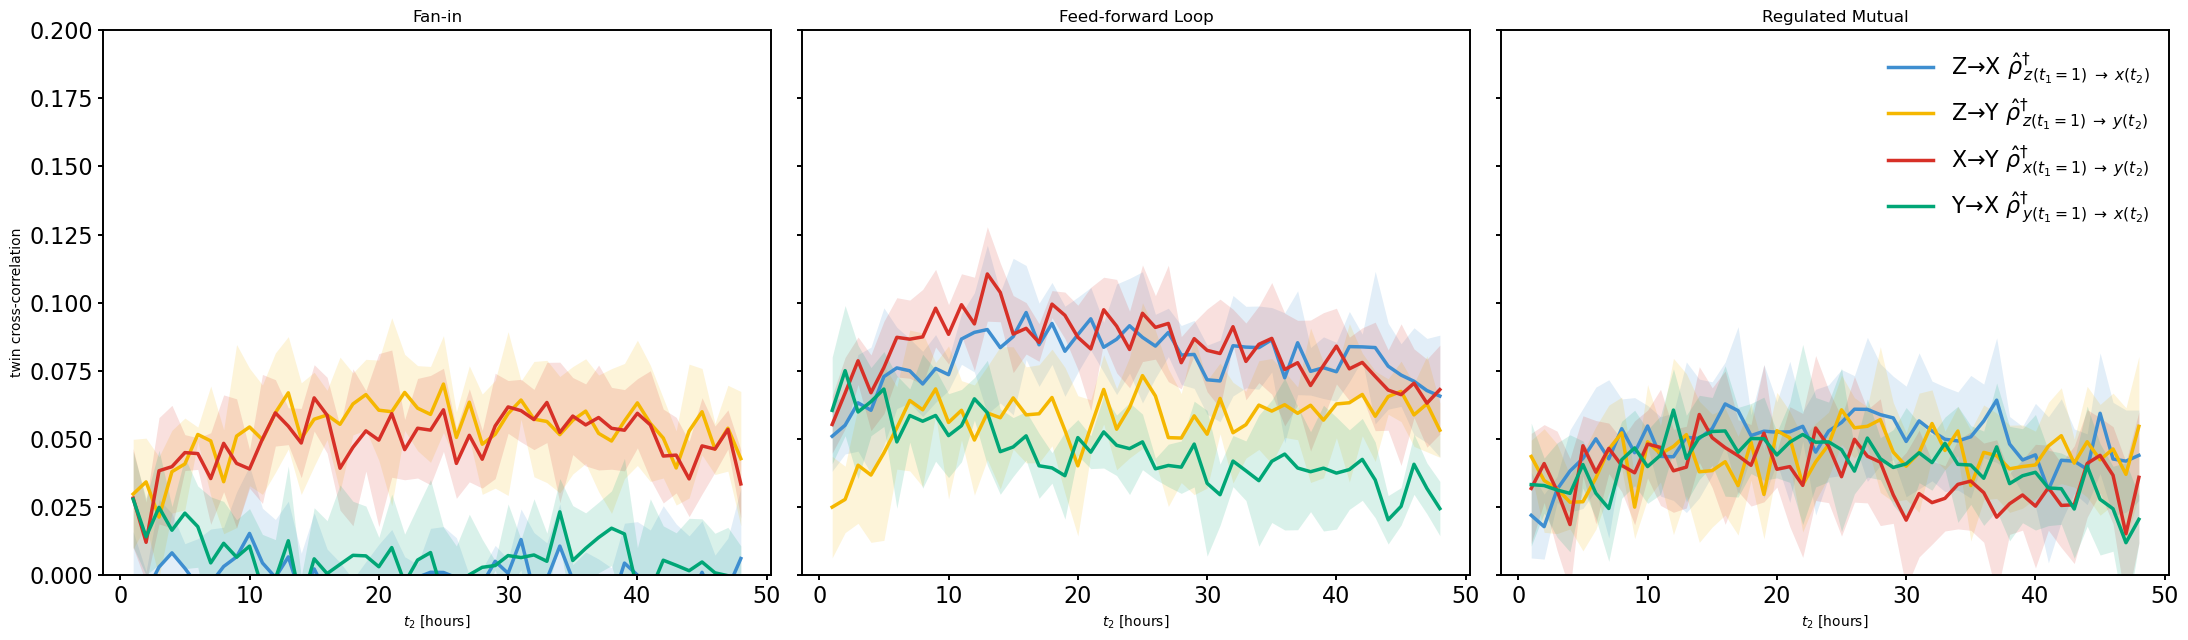

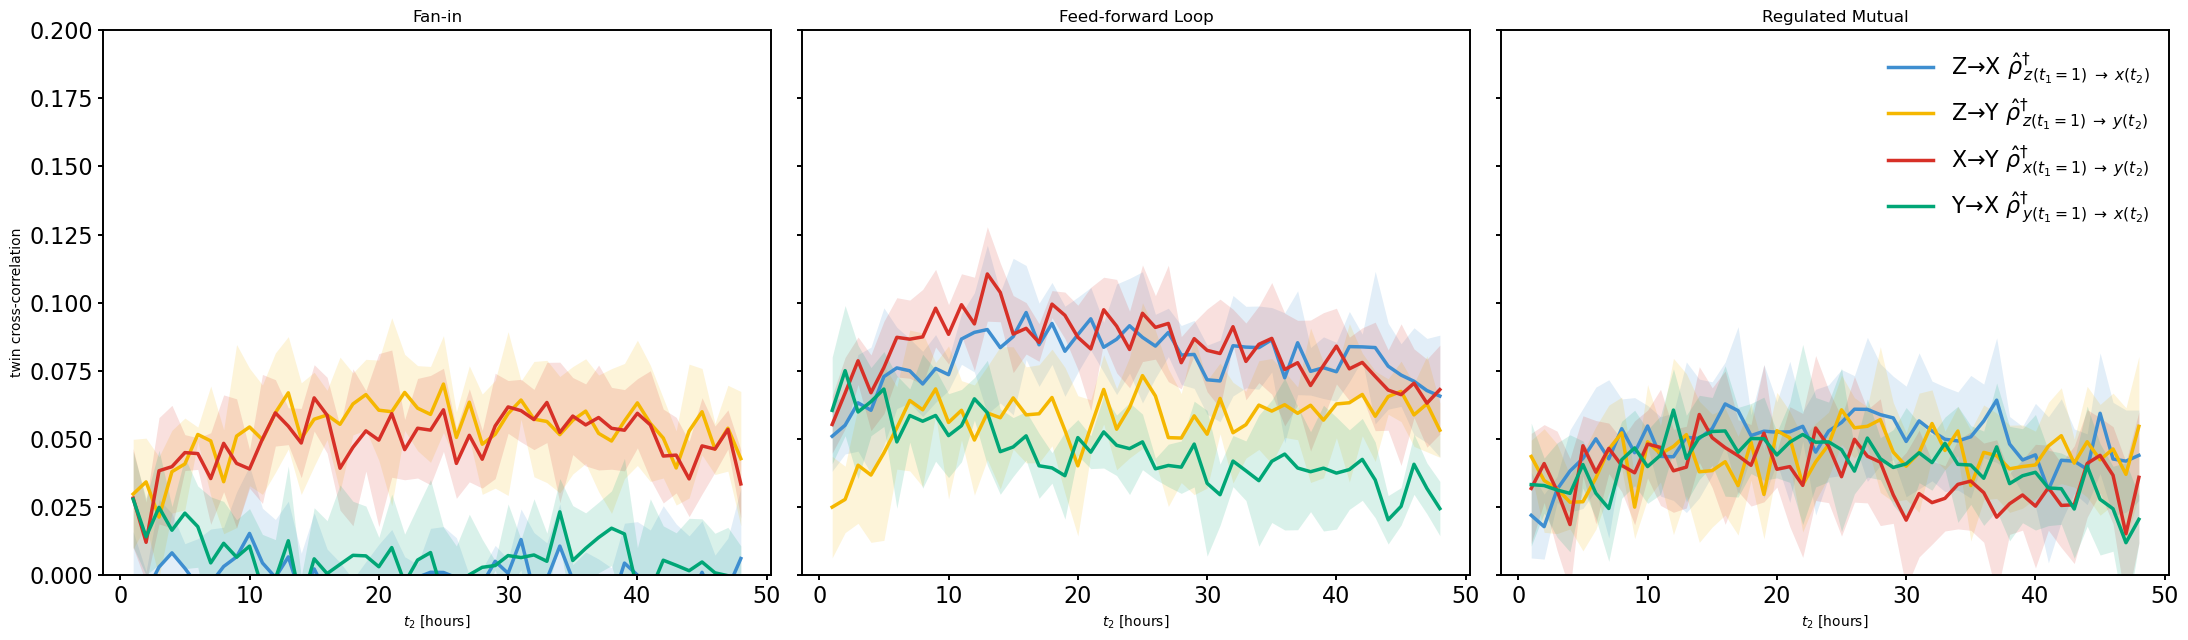

In [13]:
t1_fixed = 1
t2_values = list(range(1, 49))   # 1..48
time_col = 'time_step'

# Colors
COL_ZX = "#3E8ED0"
COL_ZY = "#F5B700"
COL_XY = "#D73027"
COL_YX = "#00A676"

# Gene columns (Z, X, Y)
y_col  = 'gene_1_mRNA'  # Z
x1_col = 'gene_2_mRNA'  # X
x2_col = 'gene_3_mRNA'  # Y

# Metrics to compute / plot
METRICS_TO_PLOT = ["Spearman(x_t1,y_t2)", "Spearman(y_t1,x_t2)"]

# Label the genes as Z, X, Y (for legend text)
GENE_LABELS = {y_col: "Z", x1_col: "X", x2_col: "Y"}

# Pair order (undirected pairs) and labels:
#   X-Y, Z-Y, Z-X
PAIR_ORDER  = [
    (x1_col, x2_col),   # X-Y
    (y_col,  x2_col),   # Z-Y
    (y_col,  x1_col),   # Z-X
]
PAIR_LABELS = {(a, b): f"{GENE_LABELS[a]}-{GENE_LABELS[b]}" for (a, b) in PAIR_ORDER}


MOTIF_RULES = {
    "Fan-out": {
        "include_all": ["Fan_out_additive", "df_rows"],
        "exclude_any": ["k_on0"],
        "max_files": 20,   # set int (e.g., 20) to cap newest files
    },
    "Feed-forward Loop": {
        "include_all": ["Feed_forward_additive", "df_rows"],
        "exclude_any": ["k_on0"],
        "max_files": 20,
    },
    "Regulated Mutual": {
        "include_all": ["Mutual_regulation_additive", "df_rows"],
        "exclude_any": ["k_on0"],
        "max_files": 20,
    },
}
tidy_twin = pd.read_csv('/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/saturation_effects/tidy_twin_3.csv')
tidy_reg = pd.read_csv('/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/saturation_effects/tidy_reg_3.csv')
agg_twin  = aggregate_mean_std(tidy_twin)
agg_reg = aggregate_mean_std(tidy_reg)
motifs_order = ['Fan-in', 'Feed-forward Loop', 'Regulated Mutual']
plot_three_motifs_panels(agg_twin, agg_reg, outpath=None, motifs_order=motifs_order)


## A -> B

In [7]:
def discover_motif_files(roots, rules, pattern="df*.csv", recursive=False, sort_by="mtime"):
    """
    Discover df*.csv files in roots, then assign them to motifs using ONLY filename checks.

    rules[motif]:
      - include_all: list[str] (filename must contain ALL substrings)  [AND]
      - exclude_any: list[str] (filename must contain NONE of these)
      - max_files: int|None    (keep newest N if sort_by='mtime')
    """
    candidates = []
    for root in roots:
        print(root)
        if recursive:
            candidates += glob.glob(os.path.join(root, "**", pattern), recursive=True)
        else:
            candidates += glob.glob(os.path.join(root, pattern))

    # de-dup and keep real files
    candidates = [p for p in dict.fromkeys(candidates) if p and os.path.isfile(p)]

    def _key(p):
        if sort_by == "name":
            return os.path.basename(p).lower()
        return os.path.getmtime(p)  # default: mtime

    out = {}
    for motif, r in rules.items():
        inc_all = [s.lower() for s in r.get("include_all", [])]
        exc_any = [s.lower() for s in r.get("exclude_any", [])]
        max_files = r.get("max_files", None)

        hits = []
        for p in candidates:
            name = os.path.basename(p).lower()

            # AND filter: must contain ALL required substrings
            if inc_all and not all(k in name for k in inc_all):
                continue

            # exclusions: must contain NONE of these
            if exc_any and any(k in name for k in exc_any):
                continue

            hits.append(p)

        if sort_by == "name":
            hits = sorted(hits, key=_key)
        else:
            hits = sorted(hits, key=_key, reverse=True)  # newest first

        if isinstance(max_files, int) and max_files > 0:
            hits = hits[:max_files]

        out[motif] = hits
        print(f"[discover] {motif}: {len(hits)} files")
        if hits:
            print("  example:", os.path.basename(hits[0]))

    return out


# ============================================================
# Helpers
# ============================================================
def _spearman(a, b):
    """Spearman rank correlation with pairwise finite masking."""
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 3:
        return np.nan
    r, _ = spearmanr(a[mask], b[mask])
    return float(r)

def detect_twins_scheme(df: pd.DataFrame):
    """
    Decide which replicate labels are twin A and twin B for this file.

    - If replicates include 0 and 1  -> A = 0, B = 1
    - Else if replicates include 1 and 2 (and no 0) -> A = 1, B = 2
    - Otherwise, raise an error.
    """
    reps = set(df["replicate"].dropna().unique())
    if {0, 1}.issubset(reps):
        return 0, 1
    elif {1, 2}.issubset(reps) and 0 not in reps:
        return 1, 2
    else:
        raise ValueError(f"Cannot infer twin scheme from replicates: {sorted(reps)}")

# ============================================================
# Twins: cross-time Spearman (twin A @ t1, twin B @ t2)
# with HALF the clones used for cross-twin pairs
# ============================================================
def spearman_cross_twins_per_file_like_matrix(
    filepath,
    t1,
    t2,
    time_col=None,
    x1_col=None,
    x2_col=None,
    rep_t1=None,
    rep_t2=None,
    type_comparison="twin",  # "twin" or "random"
) -> pd.DataFrame:
    """
    Compute cross-time Spearman correlations using *half* the clones as real twins.

    For each undirected gene pair (g1, g2) in PAIR_ORDER, return:
      - Spearman(x_t1,y_t2): g1(t1, A) vs g2(t2, B)
      - Spearman(y_t1,x_t2): g2(t1, A) vs g1(t2, B)

    If type_comparison == "random", break twin pairing by permuting the t2 rows
    within the half-sampled set.
    """
    df = pd.read_csv(filepath)

    # decide repA/repB for THIS file
    if rep_t1 is None or rep_t2 is None:
        repA, repB = detect_twins_scheme(df)
    else:
        repA, repB = rep_t1, rep_t2

    base_cols = ["clone_id", "replicate", x1_col, x2_col]

    df_t1 = df.loc[(df[time_col] == t1) & (df["replicate"] == repA), base_cols].copy()
    df_t2 = df.loc[(df[time_col] == t2) & (df["replicate"] == repB), base_cols].copy()

    # average duplicates (if any)
    if df_t1.duplicated(subset=["clone_id"]).any():
        df_t1 = df_t1.groupby("clone_id", as_index=False).mean(numeric_only=True)
    if df_t2.duplicated(subset=["clone_id"]).any():
        df_t2 = df_t2.groupby("clone_id", as_index=False).mean(numeric_only=True)

    # strict twin safety check
    clones_t1 = set(df_t1["clone_id"])
    clones_t2 = set(df_t2["clone_id"])
    if type_comparison == "twin":
        if clones_t1 != clones_t2:
            only_t1 = sorted(clones_t1 - clones_t2)
            only_t2 = sorted(clones_t2 - clones_t1)
            print("[error] Twin mismatch between t1 and t2 for file:", filepath)
            print(f"  t1 (rep={repA}) clones: {len(clones_t1)}")
            print(f"  t2 (rep={repB}) clones: {len(clones_t2)}")
            if only_t1:
                print("  present only at t1 (first few):", only_t1[:10])
            if only_t2:
                print("  present only at t2 (first few):", only_t2[:10])
            raise ValueError("Mismatch in clone_id sets between t1 and t2 for twin comparison")

    rename_t1 = {col: f"{col}_t1" for col in [x1_col, x2_col]}
    rename_t2 = {col: f"{col}_t2" for col in [x1_col, x2_col]}
    df_t1 = df_t1.rename(columns=rename_t1)
    df_t2 = df_t2.rename(columns=rename_t2)

    merged = df_t1.merge(df_t2, on="clone_id", how="inner")
    if merged.empty:
        cols = ["gene_pair", "Spearman(x_t1,y_t2)", "Spearman(y_t1,x_t2)"]
        return pd.DataFrame(columns=cols).set_index("gene_pair")

    # HALF-sampling
    n_total = len(merged)
    if n_total >= 2:
        n_keep = n_total // 2
        idx = np.random.permutation(n_total)[:n_keep]
        merged = merged.iloc[idx].reset_index(drop=True)

    # random: break pairing
    if type_comparison == "random":
        n = len(merged)
        perm = np.random.permutation(n)
        merged_rand = merged.copy()
        for col in [f"{x1_col}_t2", f"{x2_col}_t2"]:
            merged_rand[col] = merged[col].values[perm]
        used_df = merged_rand
    else:
        used_df = merged

    rows = []
    for (g1, g2) in PAIR_ORDER:
        x_forward = used_df[f"{g1}_t1"].values
        y_forward = used_df[f"{g2}_t2"].values
        r_forward = _spearman(x_forward, y_forward)

        x_reverse = used_df[f"{g2}_t1"].values
        y_reverse = used_df[f"{g1}_t2"].values
        r_reverse = _spearman(x_reverse, y_reverse)

        rows.append({
            "gene_pair": PAIR_LABELS[(g1, g2)],
            "Spearman(x_t1,y_t2)": r_forward,
            "Spearman(y_t1,x_t2)": r_reverse,
        })

    return pd.DataFrame(rows).set_index("gene_pair")

# ============================================================
# Twins: build tidy table over t2 for all files in a motif
# ============================================================
def build_tidy_for_files(files, motif_name, t1, t2_values):
    files = [p for p in dict.fromkeys(files) if p and os.path.isfile(p)]
    if not files:
        print(f"[warn] No valid files for motif: {motif_name}")
        return pd.DataFrame(columns=["motif","file","t1","t2","gene_pair","metric","value"])

    print(f"[info] {motif_name}: using {len(files)} twin files")
    records = []
    for fp in files:
        base = os.path.basename(fp)
        for t2 in t2_values:
            try:
                tbl = spearman_cross_twins_per_file_like_matrix(
                    fp, t1, t2,
                    time_col=time_col,
                    x1_col=x1_col,
                    x2_col=x2_col,
                    type_comparison="twin",
                )
            except Exception as e:
                print(f"[warn] {motif_name} | {base} | t2={t2}: {e}")
                continue

            for gp, row in tbl.iterrows():
                for metric in METRICS_TO_PLOT:
                    val = row.get(metric, np.nan)
                    records.append({
                        "motif":     motif_name,
                        "file":      base,
                        "t1":        int(t1),
                        "t2":        int(t2),
                        "gene_pair": gp,
                        "metric":    metric,
                        "value":     None if pd.isna(val) else float(val),
                    })

    return pd.DataFrame.from_records(records)

def build_tidy_regular_for_files(files, motif_name, t_values=None, t1=None):
    files = [p for p in dict.fromkeys(files) if p and os.path.isfile(p)]
    if not files:
        print(f"[warn] No valid files for motif (regular): {motif_name}")
        return pd.DataFrame(columns=["motif","file","t1","t2","gene_pair","metric","value"])

    print(f"[info-pop] {motif_name}: computing population corr at each time")
    records = []

    for fp in files:
        base = os.path.basename(fp)
        try:
            df = pd.read_csv(fp)
        except Exception as e:
            print(f"[warn-pop] {motif_name} | {base}: {e}")
            continue

        try:
            repA, repB = detect_twins_scheme(df)
        except ValueError as e:
            print(f"[warn-pop] {motif_name} | {base}: {e}")
            continue

        if t_values is None:
            times = np.sort(df[time_col].dropna().unique())
        else:
            times = np.array(sorted(set(int(t) for t in t_values)))

        for t in times:
            sub = df[(df["replicate"] == repB) & (df[time_col] == t)].dropna(
                subset=[x1_col, x2_col]
            )
            if sub.empty:
                continue

            rho_xy = _spearman(sub[x1_col], sub[x2_col])

            for (g1, g2) in PAIR_ORDER:
                gp = PAIR_LABELS[(g1, g2)]
                if gp == "X-Y":
                    rho = rho_xy
                elif gp == "Z-Y":
                    rho = rho_zy
                elif gp == "Z-X":
                    rho = rho_zx
                else:
                    continue

                records.append({
                    "motif":     motif_name,
                    "file":      base,
                    "t1":        int(t),
                    "t2":        int(t),
                    "gene_pair": gp,
                    "metric":    "Spearman_same_time",
                    "value":     float(rho),
                })

    return pd.DataFrame.from_records(records)


# ============================================================
# Main
# ============================================================
t1_fixed = 1
t2_values = list(range(1, 49))   # 1..48
time_col = 'time_step'

# Gene columns (Z, X, Y)
x1_col = 'gene_1_mRNA'  # X
x2_col = 'gene_2_mRNA'  # Y

# Metrics to compute / plot
METRICS_TO_PLOT = ["Spearman(x_t1,y_t2)", "Spearman(y_t1,x_t2)"]

# Label the genes as Z, X, Y (for legend text)
GENE_LABELS = {x1_col: "X", x2_col: "Y"}

# Pair order (undirected pairs) and labels:
#   X-Y, Z-Y, Z-X
PAIR_ORDER  = [
    (x1_col, x2_col),   # X-Y
]
PAIR_LABELS = {(a, b): f"{GENE_LABELS[a]}-{GENE_LABELS[b]}" for (a, b) in PAIR_ORDER}


# ============================================================
# AUTO-DISCOVERY: folders + filename keywords only
# include_all = AND logic (must contain ALL keywords)
# ============================================================

MOTIF_RULES = {

    "A -> B": {
        "include_all": ["A_to_B", "df_rows", "k_add_6"],
        "exclude_any": ["k_on0"],
        "max_files": 5,
    },
}

path_to_simulation_data = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects/"
MOTIF_FILES = discover_motif_files(
    [path_to_simulation_data],
    MOTIF_RULES,
    pattern="df*.csv",
    recursive=True,   # set True if your files are in subfolders
    sort_by="mtime",
)


/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects/
[discover] A -> B: 5 files
  example: df_rows_0_0_0_17022026_183913_ncells_6000_A_to_B_k_add_6_1_9_7aeb2b18.csv


In [8]:
all_tidy_twin = []
for motif, files in MOTIF_FILES.items():
    tidy_motif = build_tidy_for_files(files, motif, t1_fixed, t2_values)
    if not tidy_motif.empty:
        all_tidy_twin.append(tidy_motif)

if not all_tidy_twin:
    raise SystemExit("[abort] No twin data collected. Check path_to_simulations / MOTIF_RULES.")
tidy_twin = pd.concat(all_tidy_twin, ignore_index=True)
all_tidy_reg = []
for motif, files in MOTIF_FILES.items():
    tidy_reg_motif = build_tidy_regular_for_files(files, motif, t_values=t2_values, t1=t1_fixed)
    if not tidy_reg_motif.empty:
        all_tidy_reg.append(tidy_reg_motif)
if not all_tidy_reg:
    raise SystemExit("[abort] No regular-corr data collected. Check path_to_simulations / MOTIF_RULES.")
tidy_twin = pd.concat(all_tidy_twin, ignore_index=True)

tidy_reg = pd.concat(all_tidy_reg, ignore_index=True)
tidy_reg.to_csv("tidy_reg_A_to_B.csv")
tidy_twin.to_csv("tidy_twin_A_to_B.csv")

[info] A -> B: using 5 twin files
[info-pop] A -> B: computing population corr at each time


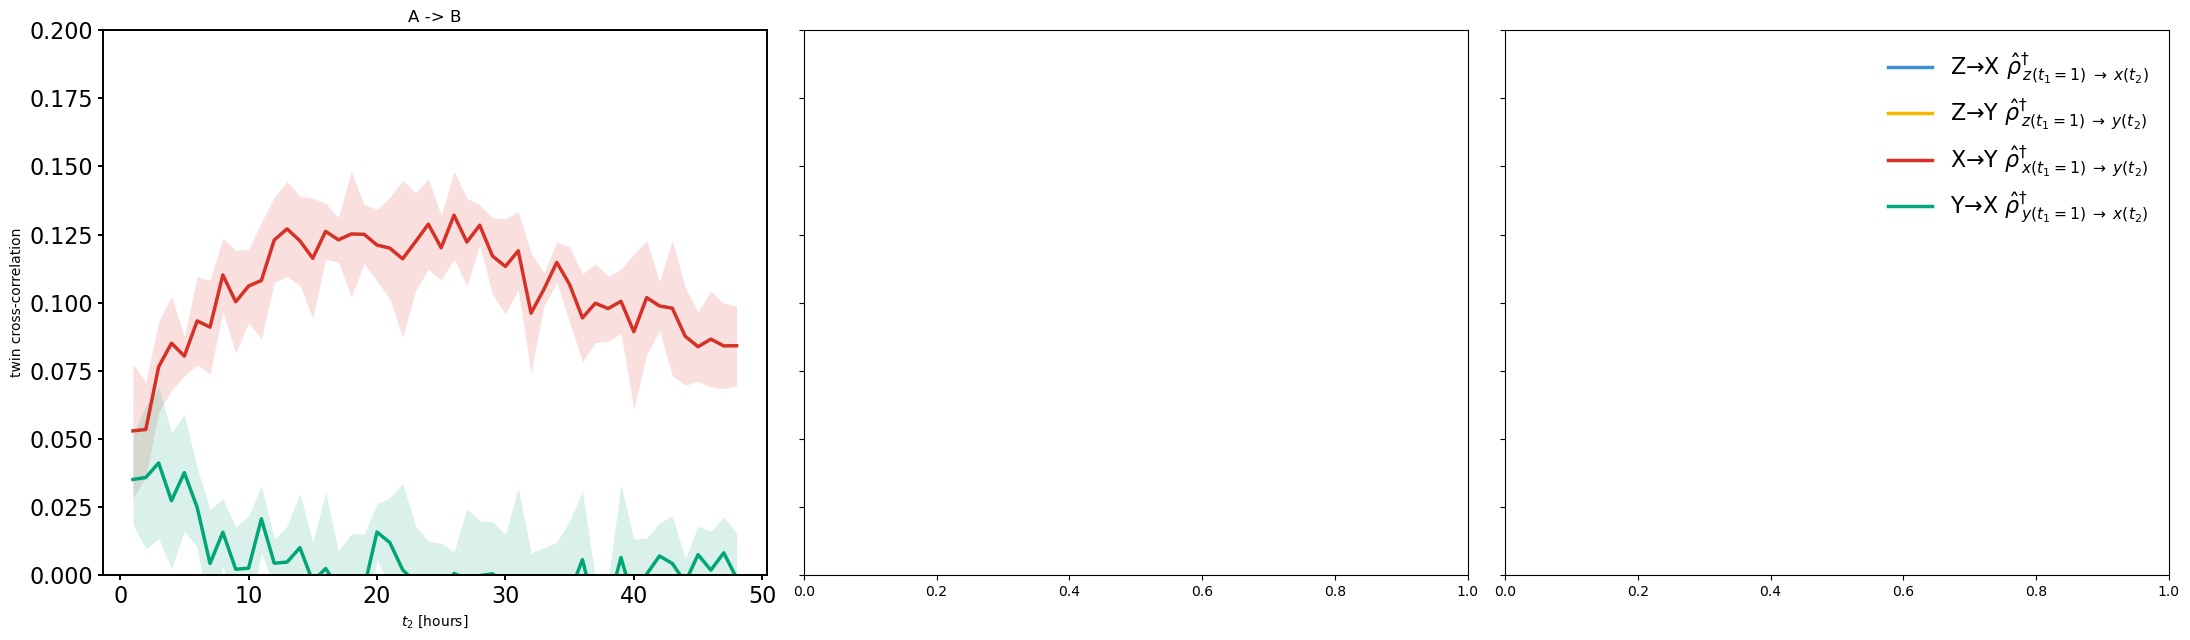

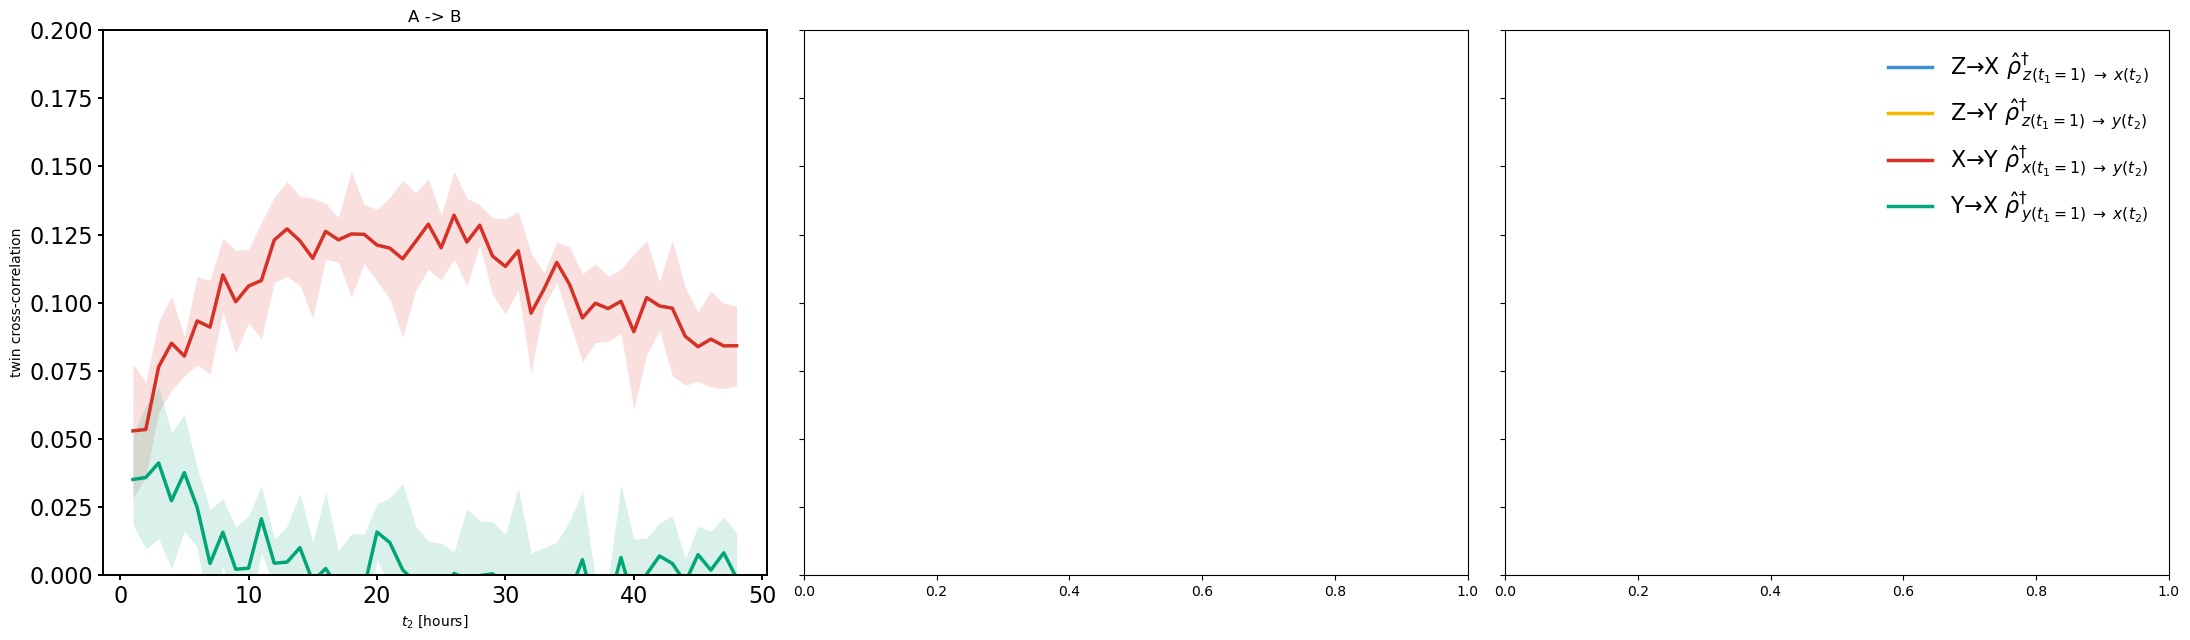

In [15]:
tidy_twin = pd.read_csv('/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/saturation_effects/tidy_twin_A_to_B.csv')
tidy_reg = pd.read_csv('/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/saturation_effects/tidy_reg_A_to_B.csv')
agg_twin  = aggregate_mean_std(tidy_twin)
agg_reg = aggregate_mean_std(tidy_reg)
motifs_order = ['A -> B']
plot_three_motifs_panels(agg_twin, agg_reg, outpath=None, motifs_order=motifs_order)

# Comparison of Unidirectional and Bidirection Cross-Correlation in Linear Model

In [14]:
#!/usr/bin/env python3

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D

In [ ]:
#!/usr/bin/env python3

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D

# ============================================================
# Fonts
# ============================================================

font_paths = [
    "/home/gzu5140/Font/Arial.ttf",
    "/home/gzu5140/Font/Arial Bold.ttf",
    "/home/gzu5140/Font/Arial Italic.ttf",
    "/home/gzu5140/Font/Arial Bold Italic.ttf",
]

for fp in font_paths:
    try:
        fm.fontManager.addfont(fp)
    except Exception:
        pass

plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = "none"
plt.rcParams['mathtext.fontset'] = "cm"
plt.rcParams['axes.labelsize'] = 25
plt.rcParams['axes.titlesize'] = 26
plt.rcParams['xtick.labelsize'] = 38
plt.rcParams['ytick.labelsize'] = 38
plt.rcParams['legend.fontsize'] = 24
plt.rcParams['figure.dpi'] = 400
plt.rcParams['axes.grid'] = False

# ============================================================
# Correlation formulas
# ============================================================

def rho_s23_xy(lam, t):
    return np.exp(-t) * (lam * (1 + 2*t)) / (2*np.sqrt(1 + lam**2/2))

def rho_s27_xy(lam, t):
    return np.exp(-t) * (lam*np.cosh(lam*t) + np.sinh(lam*t))

# ============================================================
# Plot
# ============================================================

def plot_uni_bi(lams, t_max=10, outpath=None):

    t = np.linspace(0, t_max, 1200)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(20, 6.5),
        sharey=True
    )

    axes[0].set_title(r"$X \rightarrow Y$", fontsize=38, pad=15)
    axes[1].set_title(r"$X \rightleftarrows Y$", fontsize=38, pad=15)


    colors = ["#F0E442", "#E69F00", "#D55E00", "#009E73", "#0072B2"]


    legend_handles = []

    for lam, c in zip(lams, colors):

        # Plot unidirectional
        axes[0].plot(
            t,
            rho_s23_xy(lam, t),
            lw=3,
            color=c
        )

        # Plot bidirectional (stable only)
        if abs(lam) < 1.1:
            axes[1].plot(
                t,
                rho_s27_xy(lam, t),
                lw=3,
                color=c
            )

        # Create legend handle manually
        legend_handles.append(
            Line2D(
                [], [], 
                color=c,
                lw=3,
                label=rf"$\lambda = {lam}$"
            )
        )
    for ax in axes:
        ax.set_ylim(-0.1, 1.1)

    # Axis formatting
    for ax in axes:
        ax.set_xlabel(r"$t_2$", fontsize=32)
        ax.set_xlim(0, t_max)
        ax.tick_params(labelsize=26, width=1.6)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.4)
            spine.set_edgecolor("black")

    axes[0].set_ylabel(r"$\hat{\rho}^{\dagger}_{X\to Y}(0,t_2)$", fontsize=32)

    # Place legend in right panel
    axes[0].legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(1, 1),
    frameon=False,
    fontsize=28,
    labelspacing=0.3,
    handlelength=2.2,
    handletextpad=0.6,
    borderpad=0.3
)



    fig.tight_layout()

    if outpath is not None:
        fig.savefig(
            outpath,
            format="pdf",
            bbox_inches="tight",
            dpi=400,
            facecolor="none",
            edgecolor="none",
            transparent=True
        )

    return fig


if __name__ == "__main__":

    lambdas = [0.2, 0.4, 0.6, 0.8, 1.0]

    plot_uni_bi(
        lambdas,
        t_max=2.5,
        outpath="/home/gzu5140/uni_vs_bi_comparison.pdf"
    )

    plt.show()
